<a href="https://colab.research.google.com/github/gitbidec6/Machine-Learning-Works/blob/main/CompressiveStrengthPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel('Recycled.xlsx')
df.head()

,Cement,Flyash,GGBS,MK,Water,SP,VMA,NCA_20,NCA_10,RCA_20,RCA_10,Sand,Curing_Day,Compressive Strength N/mm2)
0,550,0,0,0,165,3.30,0.28,0,0,247,337,607,7,49.71
1,385,165,0,0,148,6.05,1.10,0,0,270,432,729,7,18.53
2,275,275,0,0,146,5.50,1.10,0,0,276,441,745,7,15.09
3,165,385,0,0,172,4.40,1.10,0,0,280,448,757,7,6.34
4,385,0,165,0,155,6.60,1.38,0,0,361,417,815,7,42.83


In [ ]:
df.columns.tolist()

['Cement',
 'Flyash',
 'GGBS',
 'MK',
 'Water',
 'SP',
 'VMA',
 'NCA_20',
 'NCA_10',
 'RCA_20',
 'RCA_10',
 'Sand',
 'Curing_Day',
 'Compressive Strength N/mm2)']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Cement                       188 non-null    int64  
 1   Flyash                       188 non-null    int64  
 2   GGBS                         188 non-null    int64  
 3   MK                           188 non-null    int64  
 4   Water                        188 non-null    int64  
 5   SP                           188 non-null    float64
 6   VMA                          188 non-null    float64
 7   NCA_20                       188 non-null    int64  
 8   NCA_10                       188 non-null    int64  
 9   RCA_20                       188 non-null    int64  
 10  RCA_10                       188 non-null    int64  
 11  Sand                         188 non-null    int64  
 12  Curing_Day                   188 non-null    int64  
 13  Compressive Strength

In [ ]:
df.isnull().sum()

,0
Cement,0
Flyash,0
GGBS,0
MK,0
Water,0
SP,0
VMA,0
NCA_20,0
NCA_10,0
RCA_20,0


In [ ]:
df.describe()

,Cement,Flyash,GGBS,MK,Water,SP,VMA,NCA_20,NCA_10,RCA_20,RCA_10,Sand,Curing_Day,Compressive Strength N/mm2)
count,188.000000,188.00000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000
mean,338.574468,50.00000,60.021277,11.446809,170.446809,2.506218,0.334043,37.452128,37.053191,387.063830,484.457447,646.563830,27.452128,34.418404
std,146.911774,101.26473,113.019328,26.732830,14.172065,2.303849,0.496071,143.861278,142.330366,126.338338,147.473240,80.977657,28.366261,17.938460
min,113.000000,0.00000,0.000000,0.000000,146.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,516.000000,3.000000,6.000000
25%,227.000000,0.00000,0.000000,0.000000,170.000000,0.463750,0.000000,0.000000,0.000000,340.000000,447.000000,558.000000,7.000000,18.000000
50%,309.000000,0.00000,0.000000,0.000000,170.000000,1.950000,0.000000,0.000000,0.000000,412.000000,514.000000,653.000000,14.000000,35.000000
75%,468.000000,68.00000,113.000000,0.000000,170.000000,4.400000,1.100000,0.000000,0.000000,482.000000,571.500000,699.250000,28.000000,48.297500
max,680.000000,385.00000,385.000000,102.000000,221.000000,6.600000,1.380000,604.000000,598.000000,516.000000,633.000000,815.000000,90.000000,73.760000


In [ ]:
df.rename(columns={'Compressive Strength N/mm2)': 'Compressive_Strength'}, inplace=True)
print("Updated columns:", df.columns.tolist())

Updated columns: ['Cement', 'Flyash', 'GGBS', 'MK', 'Water', 'SP', 'VMA', 'NCA_20', 'NCA_10', 'RCA_20', 'RCA_10', 'Sand', 'Curing_Day', 'Compressive_Strength']


In [ ]:
X = df.drop('Compressive_Strength', axis=1)
y = df['Compressive_Strength']

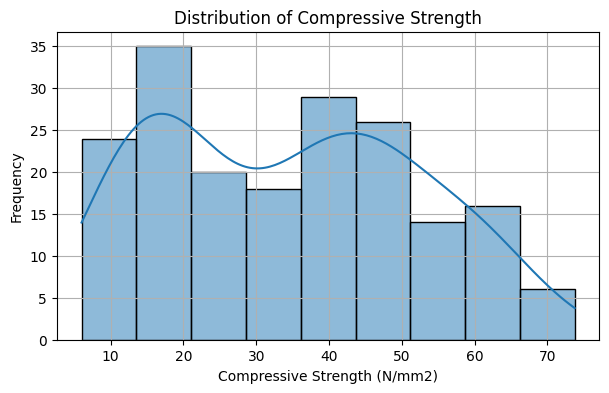

In [ ]:
plt.figure(figsize=(7, 4))
sns.histplot(y, kde=True)
plt.title('Distribution of Compressive Strength')
plt.xlabel('Compressive Strength (N/mm2)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

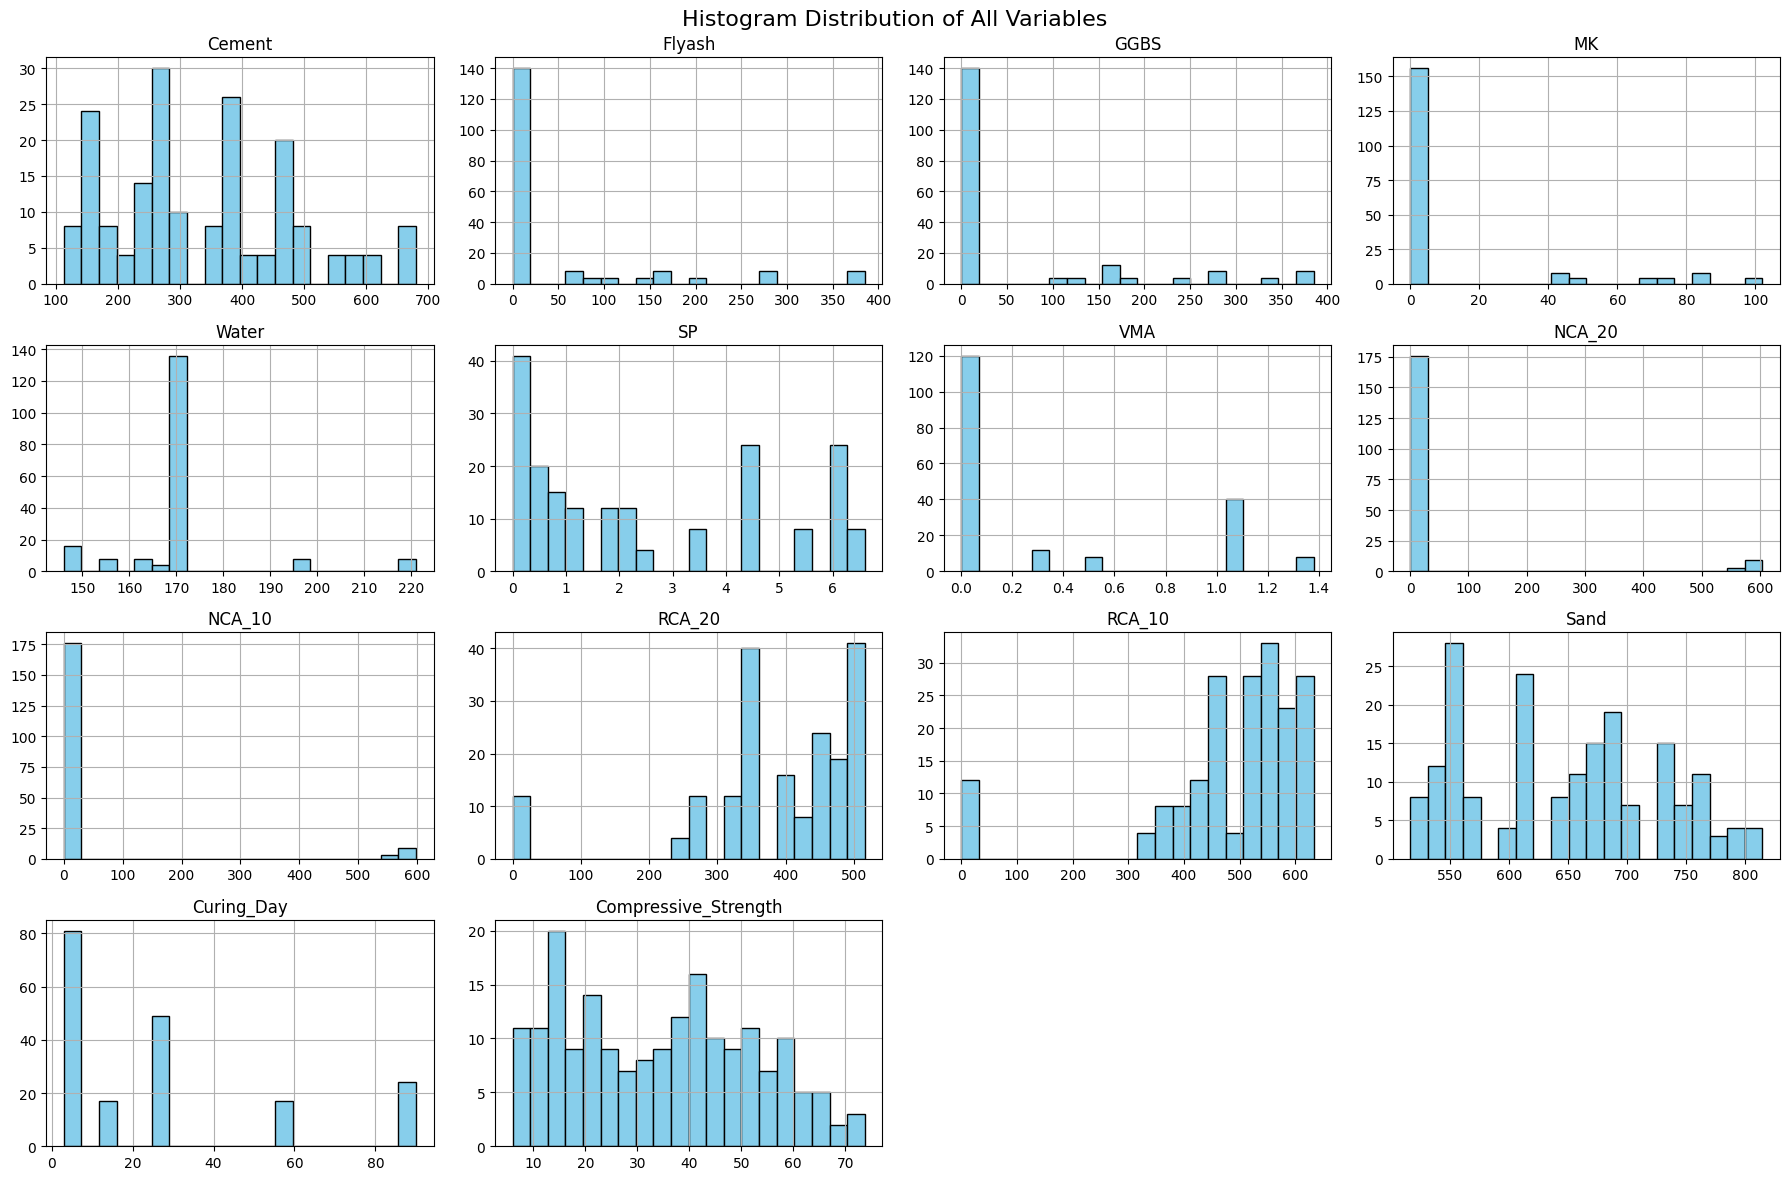

In [ ]:
df.hist(bins=20, figsize=(18, 12), color='skyblue', edgecolor='black')
plt.suptitle('Histogram Distribution of All Variables', fontsize=16,)
plt.tight_layout()
plt.show()


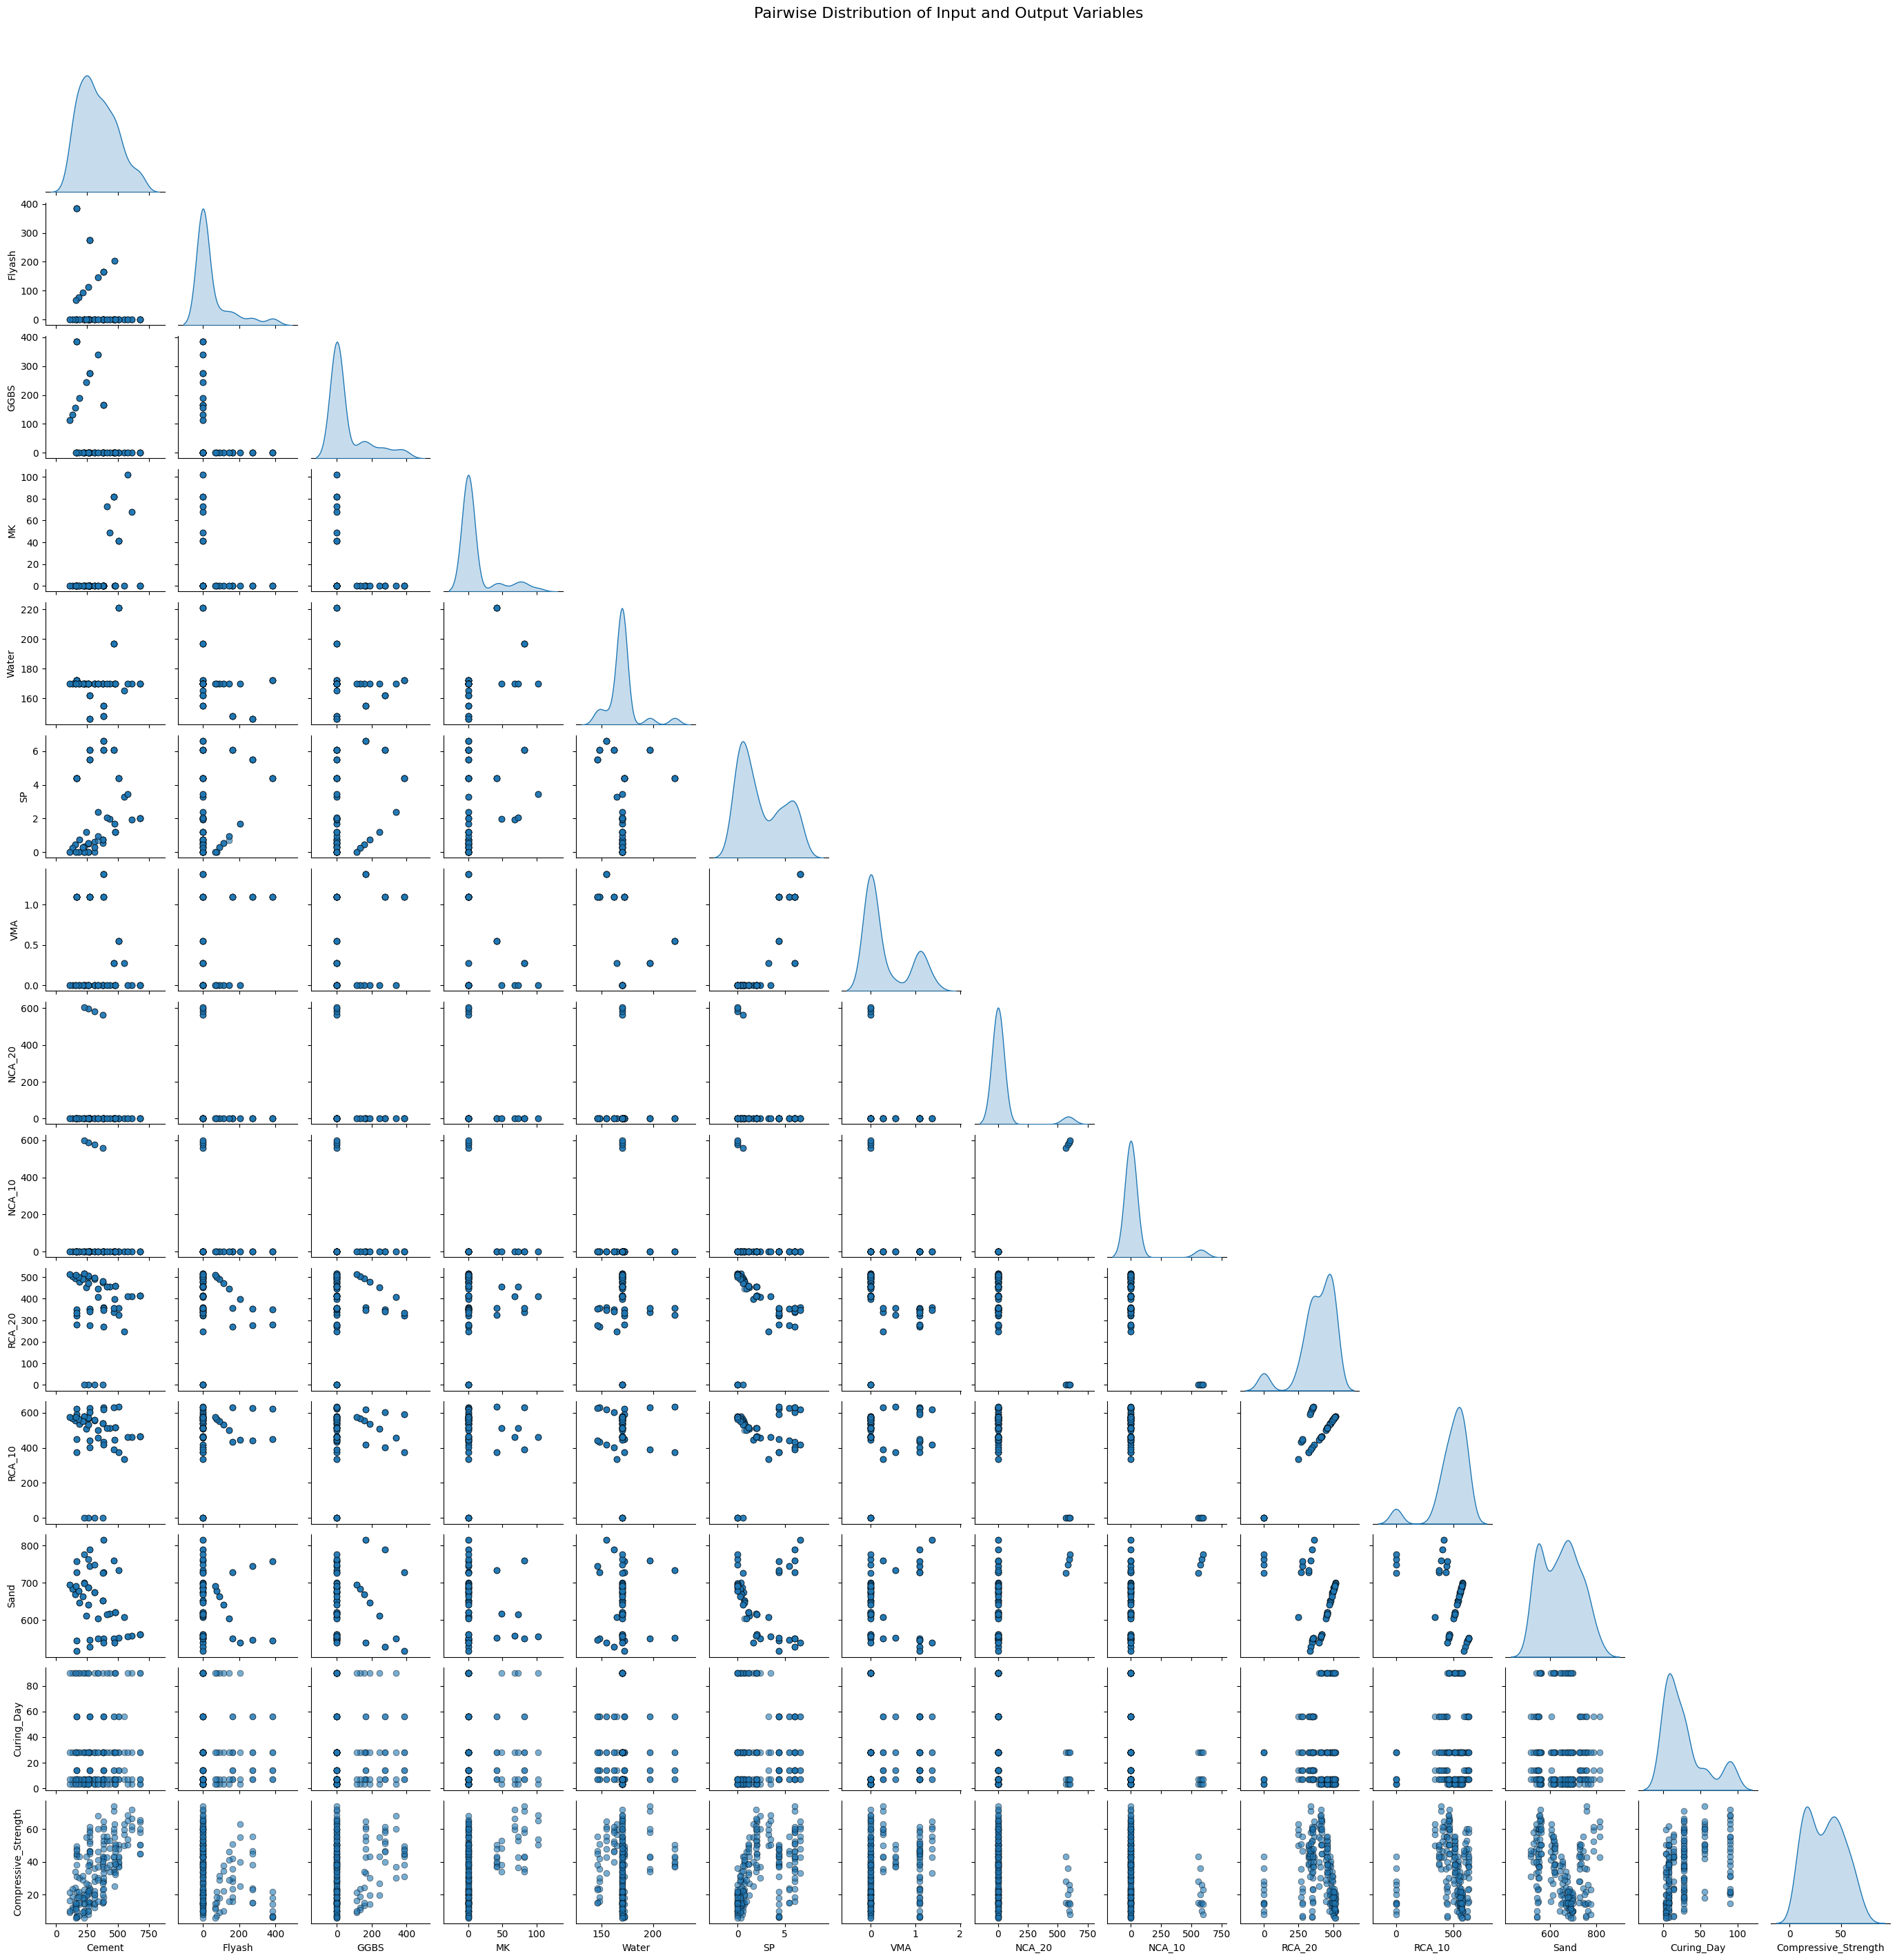

In [ ]:
sns.pairplot(df, diag_kind='kde', corner=True,
             plot_kws={"alpha": 0.6, "s": 40, "edgecolor": "k"},
             height=2.0)
plt.suptitle('Pairwise Distribution of Input and Output Variables', fontsize=16, y=1.02)
plt.show()

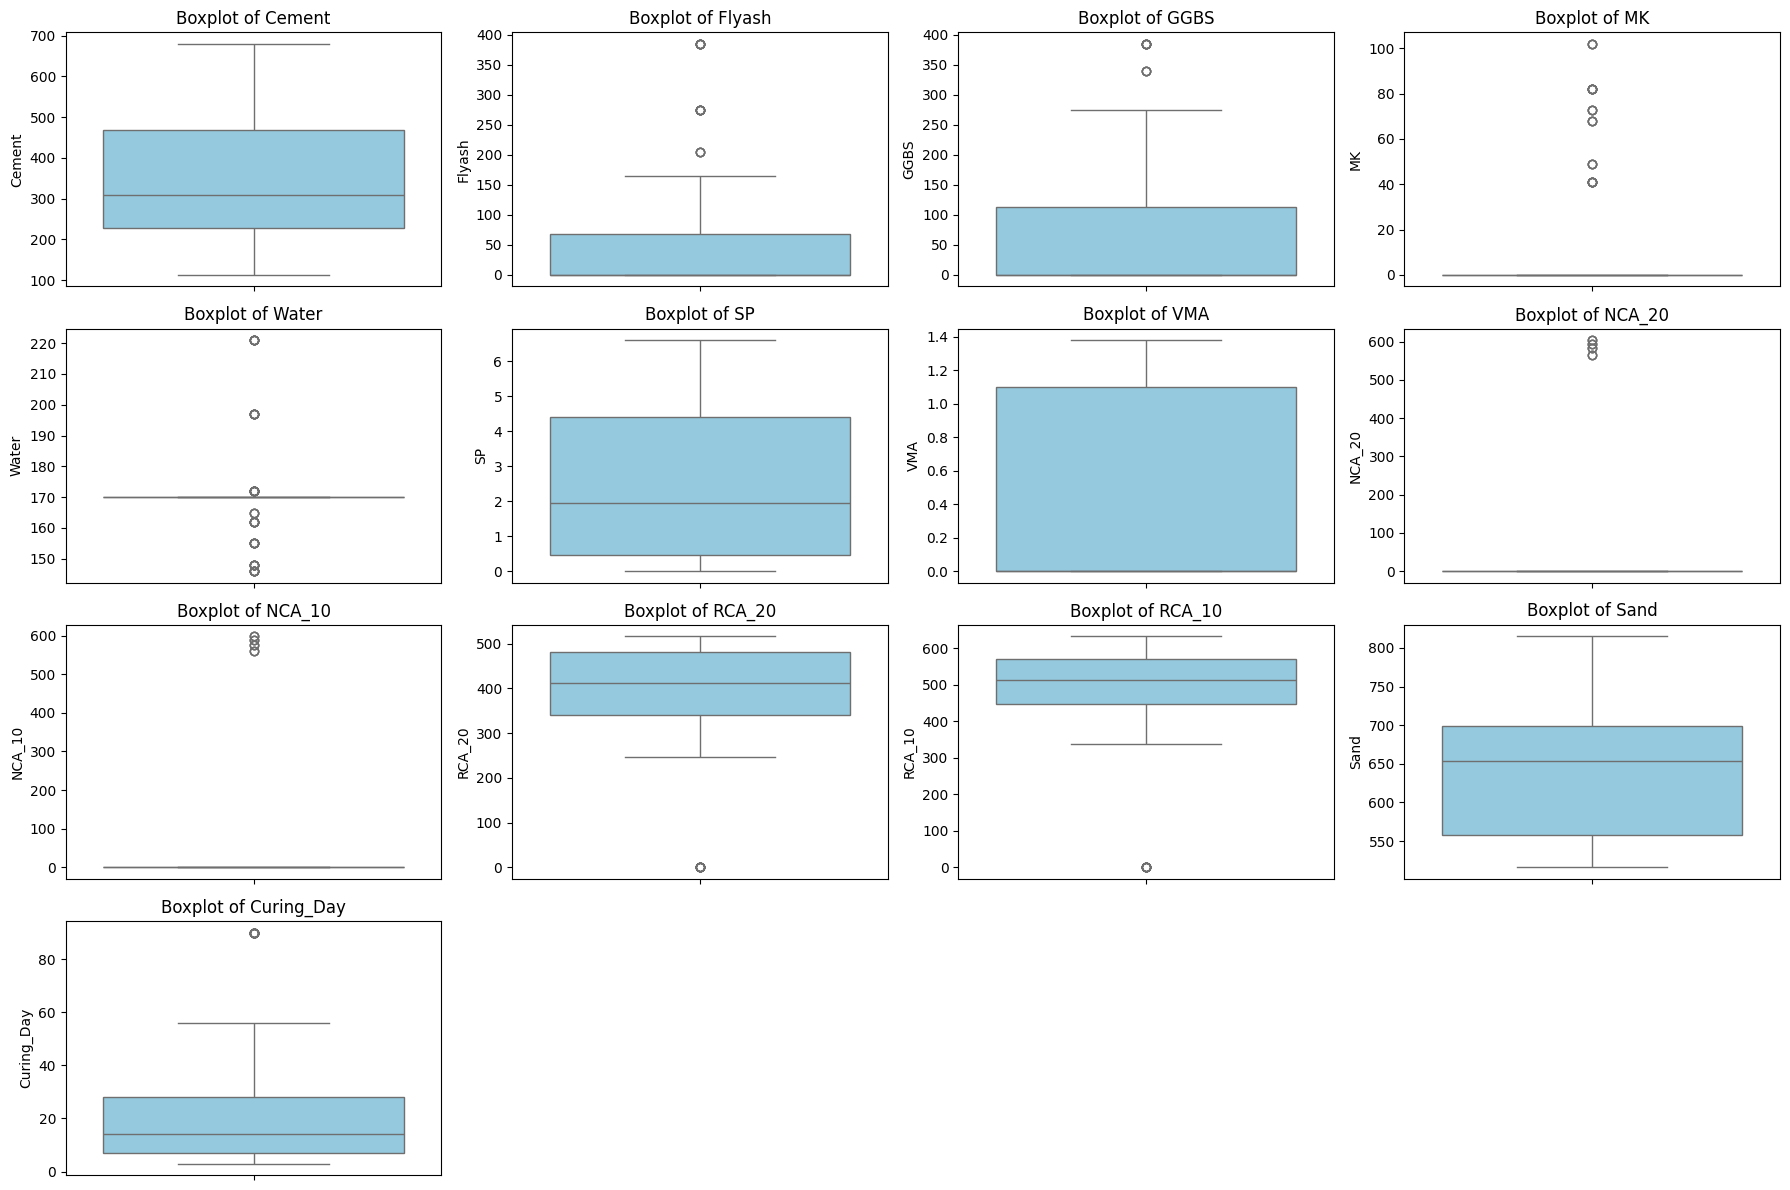

In [ ]:
plt.figure(figsize=(18, 12))

for i, column in enumerate(df.columns[:-1], 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[column], color='skyblue')
    plt.title(f'Boxplot of {column}')
    plt.tight_layout()

plt.show()


In [ ]:
from scipy.stats import zscore
import numpy as np
z_scores = np.abs(zscore(df.drop(columns=["Compressive_Strength"])))  # Exclude target
outliers = (z_scores > 3)
outlier_percentage = np.mean(outliers, axis=0) * 100
outlier_report = pd.DataFrame({
    'Feature': df.columns[:-1],
    'Outlier %': outlier_percentage
})

print(outlier_report.sort_values(by="Outlier %", ascending=False))


       Feature  Outlier %
8       NCA_10   6.382979
9       RCA_20   6.382979
10      RCA_10   6.382979
7       NCA_20   6.382979
1       Flyash   4.255319
4        Water   4.255319
3           MK   2.127660
2         GGBS   0.000000
0       Cement   0.000000
5           SP   0.000000
6          VMA   0.000000
11        Sand   0.000000
12  Curing_Day   0.000000


In [ ]:
def detect_iqr_outliers(df):
    outlier_summary = {}
    for col in df.columns[:-1]:  # Exclude target
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outlier_summary[col] = len(outliers)
    return pd.DataFrame.from_dict(outlier_summary, orient='index', columns=["# Outliers"])

iqr_outlier_report = detect_iqr_outliers(df)
print(iqr_outlier_report.sort_values("# Outliers", ascending=False))


            # Outliers
Water               68
MK                  32
Curing_Day          24
Flyash              20
GGBS                12
RCA_10              12
NCA_10              12
RCA_20              12
NCA_20              12
Cement               0
VMA                  0
SP                   0
Sand                 0


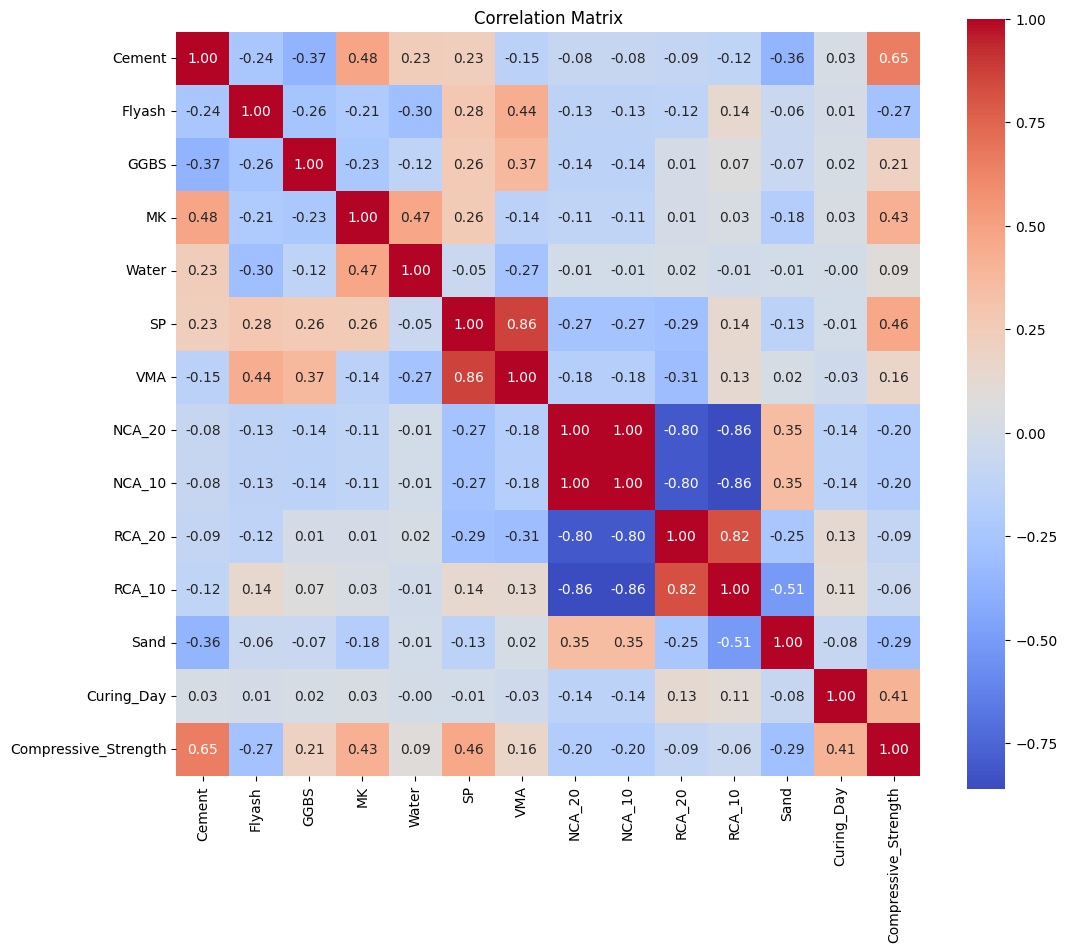

In [ ]:
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix")
plt.show()


In [ ]:
from scipy.stats import pearsonr
print("Pearson correlation with target variable:\n")
for col in X.columns:
    corr_val, p_val = pearsonr(df[col], df['Compressive_Strength'])
    print(f"{col:20} | Correlation = {corr_val:.3f}, p-value = {p_val:.3e}")


Pearson correlation with target variable:

Cement               | Correlation = 0.654, p-value = 2.466e-24
Flyash               | Correlation = -0.272, p-value = 1.602e-04
GGBS                 | Correlation = 0.206, p-value = 4.651e-03
MK                   | Correlation = 0.425, p-value = 1.186e-09
Water                | Correlation = 0.086, p-value = 2.384e-01
SP                   | Correlation = 0.465, p-value = 1.808e-11
VMA                  | Correlation = 0.165, p-value = 2.392e-02
NCA_20               | Correlation = -0.198, p-value = 6.532e-03
NCA_10               | Correlation = -0.198, p-value = 6.523e-03
RCA_20               | Correlation = -0.095, p-value = 1.965e-01
RCA_10               | Correlation = -0.060, p-value = 4.098e-01
Sand                 | Correlation = -0.290, p-value = 5.409e-05
Curing_Day           | Correlation = 0.411, p-value = 4.797e-09


In [ ]:
import numpy as np

# Step 5: Feature Engineering
df['Total_Binder'] = df['Cement'] + df['Flyash'] + df['GGBS'] + df['MK']
df['Total_Aggregate'] = df['NCA_20'] + df['NCA_10'] + df['RCA_20'] + df['RCA_10']
df['Water_Binder_Ratio'] = df['Water'] / df['Total_Binder']
df['Log_Curing_Day'] = np.log1p(df['Curing_Day'])

# Drop less useful features (optional at this point)
df.drop(columns=['RCA_10', 'Water'], inplace=True)

# Confirm changes
print("New Columns Added:")
print(df.columns.tolist())

# Update X and y
X = df.drop('Compressive_Strength', axis=1)
y = df['Compressive_Strength']


New Columns Added:
['Cement', 'Flyash', 'GGBS', 'MK', 'SP', 'VMA', 'NCA_20', 'NCA_10', 'RCA_20', 'Sand', 'Curing_Day', 'Compressive_Strength', 'Total_Binder', 'Total_Aggregate', 'Water_Binder_Ratio', 'Log_Curing_Day']


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
# Preview
print("Scaled Feature Sample:")
display(X_scaled_df.head())


Scaled Feature Sample:


,Cement,Flyash,GGBS,MK,SP,VMA,NCA_20,NCA_10,RCA_20,Sand,Curing_Day,Total_Binder,Total_Aggregate,Water_Binder_Ratio,Log_Curing_Day
0,1.442975,-0.495074,-0.532489,-0.429336,0.345466,-0.109232,-0.26103,-0.261027,-1.111601,-0.489882,-0.722927,0.620856,-2.592753,-0.733107,-0.736503
1,0.316853,1.138670,-0.532489,-0.429336,1.542308,1.548172,-0.26103,-0.261027,-0.929064,1.020730,-0.722927,0.620856,-1.747664,-0.923289,-0.736503
2,-0.433895,2.227832,-0.532489,-0.429336,1.302940,1.548172,-0.26103,-0.261027,-0.881446,1.218843,-0.722927,0.620856,-1.640237,-0.945663,-0.736503
3,-1.184643,3.316994,-0.532489,-0.429336,0.824203,1.548172,-0.26103,-0.261027,-0.849700,1.367427,-0.722927,0.620856,-1.561457,-0.654796,-0.736503
4,0.316853,-0.495074,0.931337,-0.429336,1.781677,2.114114,-0.26103,-0.261027,-0.206853,2.085587,-0.722927,0.620856,-1.203369,-0.844978,-0.736503


/tmp/ipython-input-3702701905.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_rf.values, y=importances_rf.index, palette='viridis')


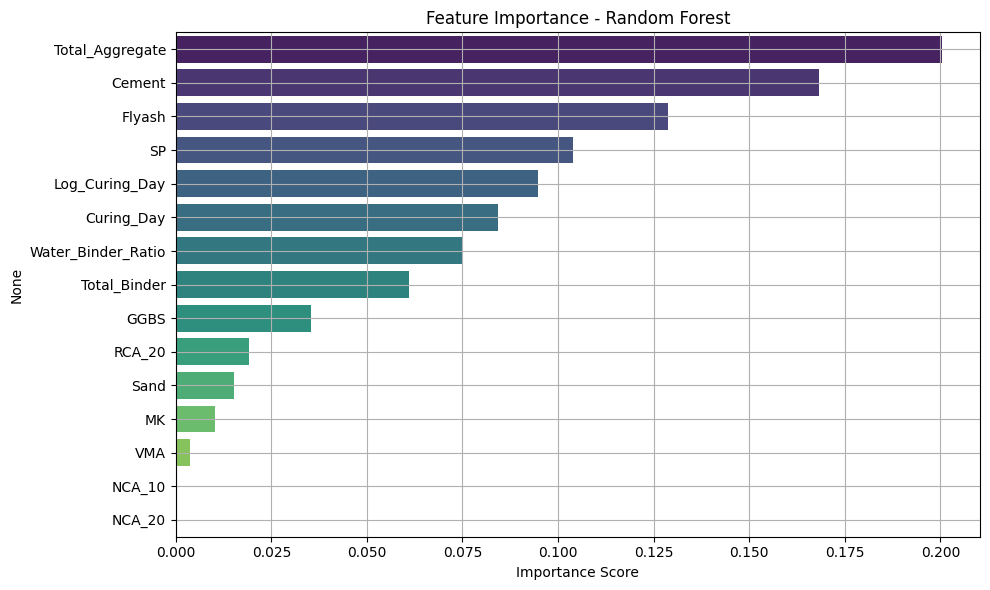

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_scaled_df, y)
importances_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances_rf.values, y=importances_rf.index, palette='viridis')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.grid(True)
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

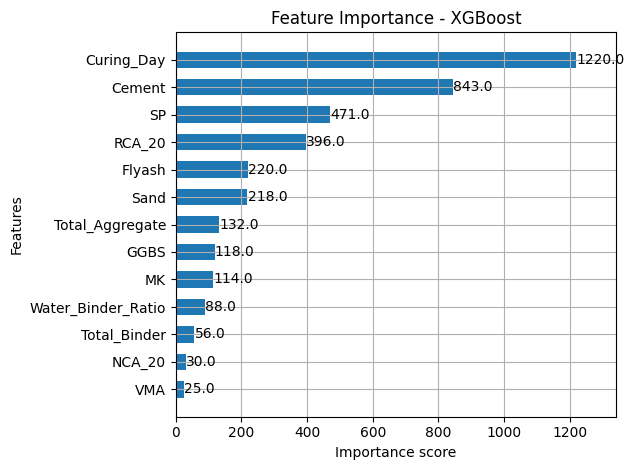

In [ ]:
from xgboost import XGBRegressor
from xgboost import plot_importance
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_scaled_df, y)
plt.figure(figsize=(10, 6))
plot_importance(xgb, height=0.6, importance_type='weight', title='Feature Importance - XGBoost')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
import numpy as np
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (y_test.max() - y_test.min())
    mape = mean_absolute_percentage_error(y_test, y_pred)
    print(f"{name} Performance:")
    print(f"R² Score: {r2:.3f}")
    print(f"MAE: {mae:.3f}")
    print(f"MSE: {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"NRMSE: {nrmse:.3f}")
    print(f"MAPE: {mape:.3f}")
    print("-" * 30)

    return r2, mae, mse, rmse, nrmse, mape


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
evaluate_model("KNN", knn, X_test, y_test)


KNN Performance:
R² Score: 0.855
MAE: 5.126
MSE: 40.773
RMSE: 6.385
NRMSE: 0.107
MAPE: 0.183
------------------------------


(0.8549462804946031,
 5.126315789473685,
 40.772905473684226,
 np.float64(6.385366510521085),
 np.float64(0.10654708010213723),
 0.1826783165293767)

In [ ]:
# modification

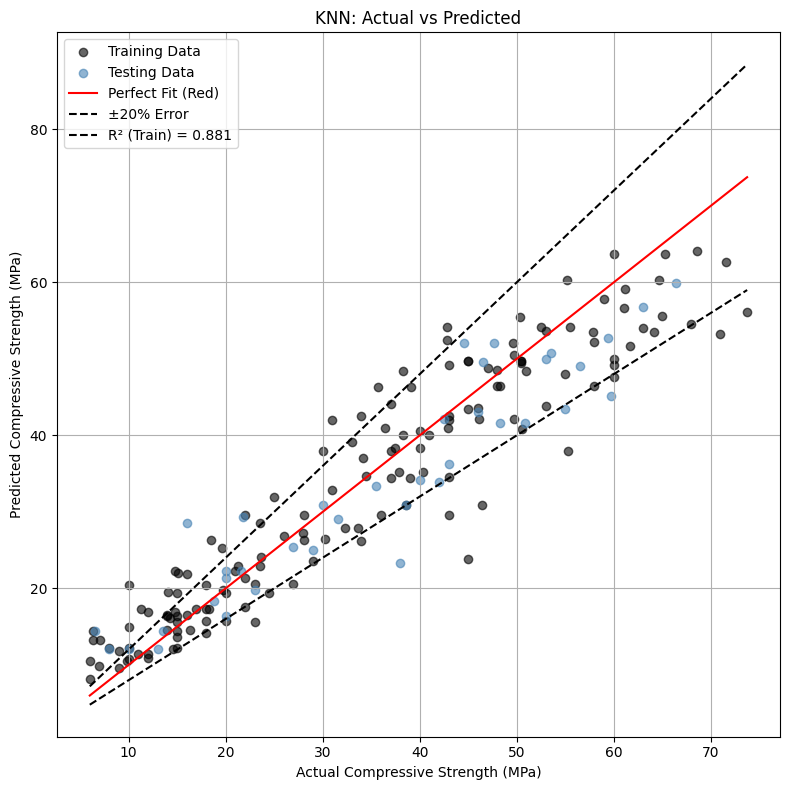

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

def plot_with_error_band(knn, X_train, X_test, y_train, y_test, model_name="Model", error_pct=0.20):
    # Predictions
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # R² scores
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Setup figure
    plt.figure(figsize=(8, 8))

    # Scatter plots
    plt.scatter(y_train, y_train_pred, color='black', alpha=0.6, label='Training Data')
    plt.scatter(y_test, y_test_pred, color='steelblue', alpha=0.6, label='Testing Data')

    # Perfect fit line
    min_val = min(y_train.min(), y_test.min())
    max_val = max(y_train.max(), y_test.max())
    x_vals = np.linspace(min_val, max_val, 100)
    plt.plot(x_vals, x_vals, 'r-', label='Perfect Fit (Red)')

    # ± error band (percentage)
    plt.plot(x_vals, x_vals * (1 + error_pct), 'k--', label=f'±{int(error_pct*100)}% Error')
    plt.plot(x_vals, x_vals * (1 - error_pct), 'k--')

    # Labels and legend
    plt.xlabel("Actual Compressive Strength (MPa)")
    plt.ylabel("Predicted Compressive Strength (MPa)")
    plt.title(f"{model_name}: Actual vs Predicted")

    # Extended legend with R² values
    plt.legend([
        'Training Data',
        'Testing Data',
        'Perfect Fit (Red)',
        f'±{int(error_pct*100)}% Error',
        f"R² (Train) = {r2_train:.3f}",
        f"R² (Test) = {r2_test:.3f}"
    ], loc="upper left")

    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_with_error_band(knn, X_train, X_test, y_train, y_test, model_name="KNN", error_pct=0.20)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

def plot_actual_vs_predicted_with_errors(knn, X_train, X_test, y_train, y_test, model_name="KNN"):
    # Predict
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # R²
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Set up plot
    plt.figure(figsize=(10, 6))

    # Plot training data points
    plt.scatter(y_train, y_train_pred, color='blue', label=f'Train (R² = {r2_train:.3f})', alpha=0.6)
    # Error lines for training
    for actual, pred in zip(y_train, y_train_pred):
        plt.plot([actual, actual], [actual, pred], color='blue', alpha=0.2)

    # Plot testing data points
    plt.scatter(y_test, y_test_pred, color='orange', label=f'Test (R² = {r2_test:.3f})', alpha=0.6)
    # Error lines for testing
    for actual, pred in zip(y_test, y_test_pred):
        plt.plot([actual, actual], [actual, pred], color='orange', alpha=0.2)

    # Perfect prediction line
    min_val = min(y_train.min(), y_test.min())
    max_val = max(y_train.max(), y_test.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Fit (y = x)', linewidth=2)

    # Labels and legend
    plt.xlabel("Actual Compressive Strength")
    plt.ylabel("Predicted Compressive Strength")
    plt.title(f"{model_name} – Actual vs Predicted with Errors")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


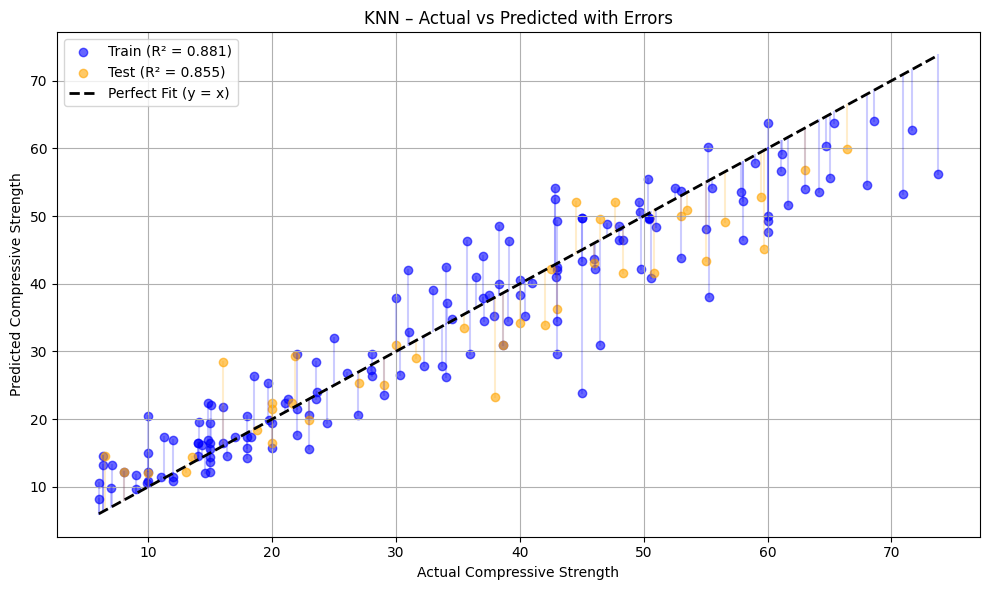

In [ ]:
plot_actual_vs_predicted_with_errors(knn, X_train, X_test, y_train, y_test, model_name="KNN")


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
evaluate_model("Random Forest", rf, X_test, y_test)


Random Forest Performance:
R² Score: 0.892
MAE: 3.999
MSE: 30.492
RMSE: 5.522
NRMSE: 0.092
MAPE: 0.146
------------------------------


(0.8915231395812262,
 3.999298771929824,
 30.491577816948997,
 np.float64(5.521917947321293),
 np.float64(0.09213946182748693),
 0.14550925952338617)

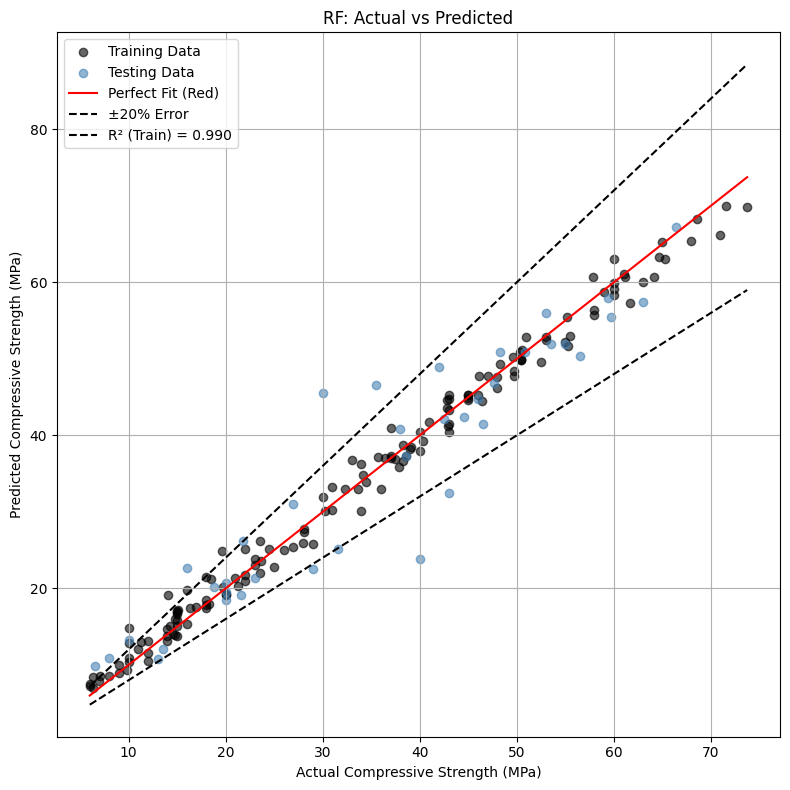

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

def plot_with_error_band(rf, X_train, X_test, y_train, y_test, model_name="RF", error_pct=0.20):
    # Predictions
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)

    # R² scores
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Setup figure
    plt.figure(figsize=(8, 8))

    # Scatter plots
    plt.scatter(y_train, y_train_pred, color='black', alpha=0.6, label='Training Data')
    plt.scatter(y_test, y_test_pred, color='steelblue', alpha=0.6, label='Testing Data')

    # Perfect fit line
    min_val = min(y_train.min(), y_test.min())
    max_val = max(y_train.max(), y_test.max())
    x_vals = np.linspace(min_val, max_val, 100)
    plt.plot(x_vals, x_vals, 'r-', label='Perfect Fit (Red)')

    # ± error band (percentage)
    plt.plot(x_vals, x_vals * (1 + error_pct), 'k--', label=f'±{int(error_pct*100)}% Error')
    plt.plot(x_vals, x_vals * (1 - error_pct), 'k--')

    # Labels and legend
    plt.xlabel("Actual Compressive Strength (MPa)")
    plt.ylabel("Predicted Compressive Strength (MPa)")
    plt.title(f"{model_name}: Actual vs Predicted")

    # Extended legend with R² values
    plt.legend([
        'Training Data',
        'Testing Data',
        'Perfect Fit (Red)',
        f'±{int(error_pct*100)}% Error',
        f"R² (Train) = {r2_train:.3f}",
        f"R² (Test) = {r2_test:.3f}"
    ], loc="upper left")

    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_with_error_band(rf, X_train, X_test, y_train, y_test, model_name="RF", error_pct=0.20)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

def plot_actual_vs_predicted_with_errors(rf, X_train, X_test, y_train, y_test, model_name="RF"):
    # Predict
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)

    # R²
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Set up plot
    plt.figure(figsize=(10, 6))

    # Plot training data points
    plt.scatter(y_train, y_train_pred, color='blue', label=f'Train (R² = {r2_train:.3f})', alpha=0.6)
    # Error lines for training
    for actual, pred in zip(y_train, y_train_pred):
        plt.plot([actual, actual], [actual, pred], color='blue', alpha=0.2)

    # Plot testing data points
    plt.scatter(y_test, y_test_pred, color='orange', label=f'Test (R² = {r2_test:.3f})', alpha=0.6)
    # Error lines for testing
    for actual, pred in zip(y_test, y_test_pred):
        plt.plot([actual, actual], [actual, pred], color='orange', alpha=0.2)

    # Perfect prediction line
    min_val = min(y_train.min(), y_test.min())
    max_val = max(y_train.max(), y_test.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Fit (y = x)', linewidth=2)

    # Labels and legend
    plt.xlabel("Actual Compressive Strength")
    plt.ylabel("Predicted Compressive Strength")
    plt.title(f"{model_name} – Actual vs Predicted with Errors")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

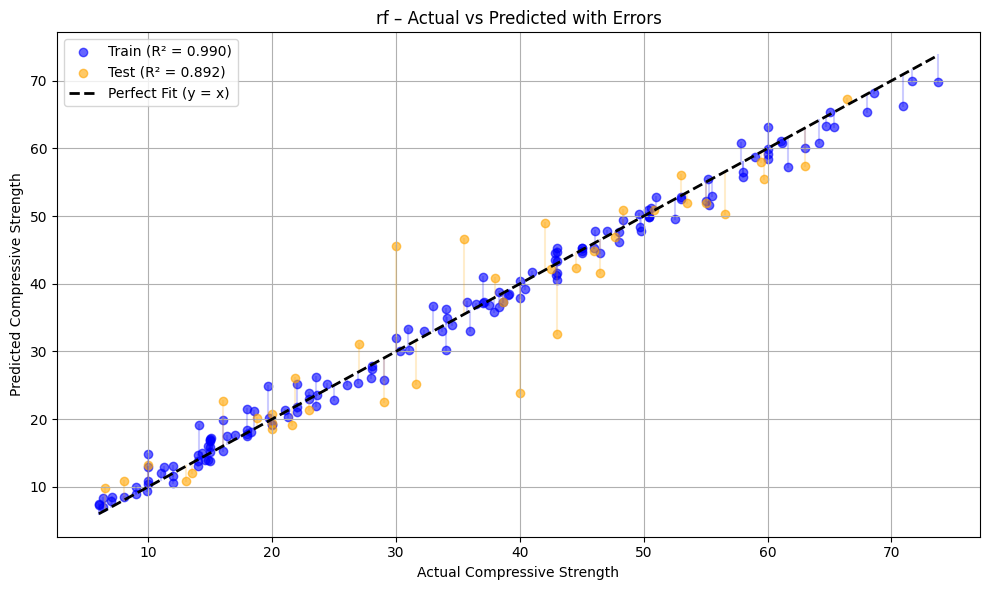

In [ ]:
plot_actual_vs_predicted_with_errors(rf, X_train, X_test, y_train, y_test, model_name="rf")

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
evaluate_model("XGBoost", xgb, X_test, y_test)


XGBoost Performance:
R² Score: 0.910
MAE: 3.280
MSE: 25.369
RMSE: 5.037
NRMSE: 0.084
MAPE: 0.107
------------------------------


(0.909748491101497,
 3.2799259120539617,
 25.368644483736386,
 np.float64(5.036729542444818),
 np.float64(0.08404354317445048),
 0.10654383426061054)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

def plot_actual_vs_predicted_with_errors(xgb, X_train, X_test, y_train, y_test, model_name="XGB"):
    # Predict
    y_train_pred = xgb.predict(X_train)
    y_test_pred = xgb.predict(X_test)

    # R²
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Set up plot
    plt.figure(figsize=(10, 6))

    # Plot training data points
    plt.scatter(y_train, y_train_pred, color='blue', label=f'Train (R² = {r2_train:.3f})', alpha=0.6)
    # Error lines for training
    for actual, pred in zip(y_train, y_train_pred):
        plt.plot([actual, actual], [actual, pred], color='blue', alpha=0.2)

    # Plot testing data points
    plt.scatter(y_test, y_test_pred, color='orange', label=f'Test (R² = {r2_test:.3f})', alpha=0.6)
    # Error lines for testing
    for actual, pred in zip(y_test, y_test_pred):
        plt.plot([actual, actual], [actual, pred], color='orange', alpha=0.2)

    # Perfect prediction line
    min_val = min(y_train.min(), y_test.min())
    max_val = max(y_train.max(), y_test.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Fit (y = x)', linewidth=2)

    # Labels and legend
    plt.xlabel("Actual Compressive Strength")
    plt.ylabel("Predicted Compressive Strength")
    plt.title(f"{model_name} – Actual vs Predicted with Errors")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

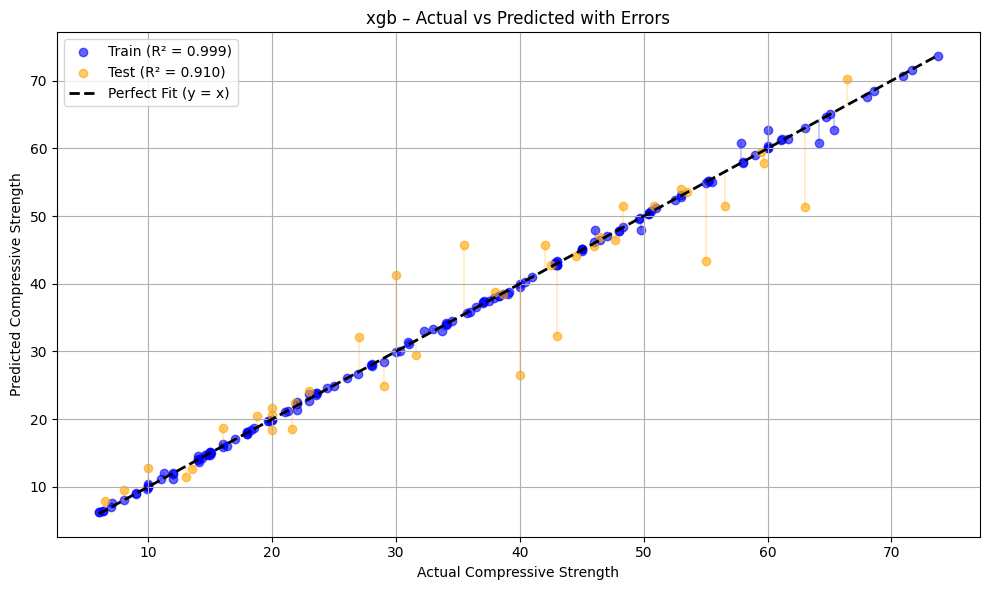

In [ ]:
plot_actual_vs_predicted_with_errors(xgb, X_train, X_test, y_train, y_test, model_name="xgb")

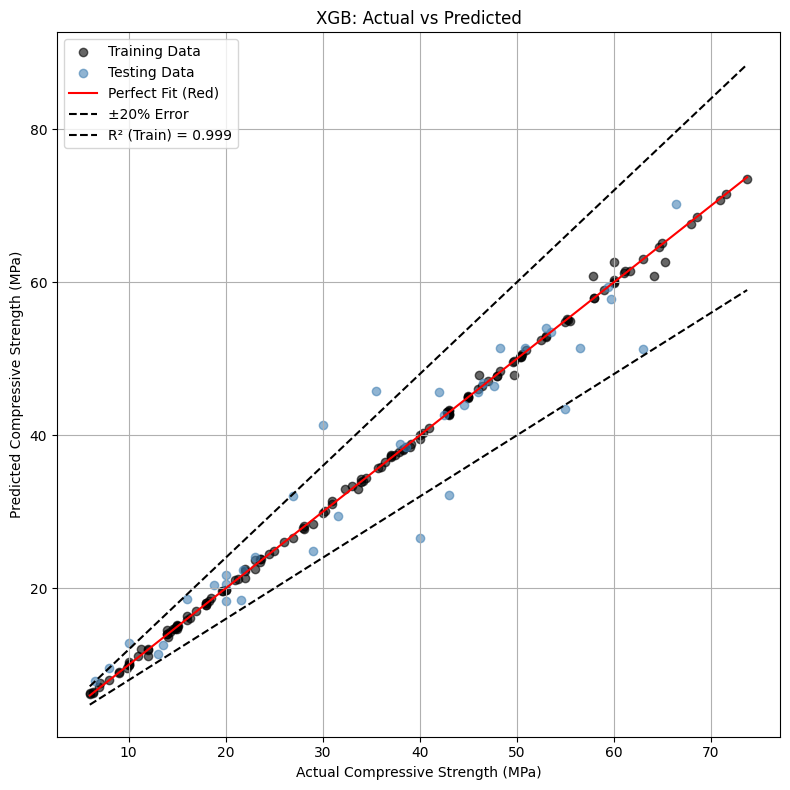

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

def plot_with_error_band(xgb, X_train, X_test, y_train, y_test, model_name="XGB", error_pct=0.20):
    # Predictions
    y_train_pred = xgb.predict(X_train)
    y_test_pred = xgb.predict(X_test)

    # R² scores
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Setup figure
    plt.figure(figsize=(8, 8))

    # Scatter plots
    plt.scatter(y_train, y_train_pred, color='black', alpha=0.6, label='Training Data')
    plt.scatter(y_test, y_test_pred, color='steelblue', alpha=0.6, label='Testing Data')

    # Perfect fit line
    min_val = min(y_train.min(), y_test.min())
    max_val = max(y_train.max(), y_test.max())
    x_vals = np.linspace(min_val, max_val, 100)
    plt.plot(x_vals, x_vals, 'r-', label='Perfect Fit (Red)')

    # ± error band (percentage)
    plt.plot(x_vals, x_vals * (1 + error_pct), 'k--', label=f'±{int(error_pct*100)}% Error')
    plt.plot(x_vals, x_vals * (1 - error_pct), 'k--')

    # Labels and legend
    plt.xlabel("Actual Compressive Strength (MPa)")
    plt.ylabel("Predicted Compressive Strength (MPa)")
    plt.title(f"{model_name}: Actual vs Predicted")

    # Extended legend with R² values
    plt.legend([
        'Training Data',
        'Testing Data',
        'Perfect Fit (Red)',
        f'±{int(error_pct*100)}% Error',
        f"R² (Train) = {r2_train:.3f}",
        f"R² (Test) = {r2_test:.3f}"
    ], loc="upper left")

    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_with_error_band(xgb, X_train, X_test, y_train, y_test, model_name="XGB", error_pct=0.20)

In [ ]:
from sklearn.svm import SVR

svm = SVR(kernel='rbf', C=1.0)
svm.fit(X_train, y_train)
evaluate_model("SVM", svm, X_test, y_test)


SVM Performance:
R² Score: 0.649
MAE: 8.103
MSE: 98.752
RMSE: 9.937
NRMSE: 0.166
MAPE: 0.339
------------------------------


(0.648680547525452,
 8.102719358988372,
 98.7517926162403,
 np.float64(9.93739365307827),
 np.float64(0.16581668034504038),
 0.3394075966895654)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

def plot_actual_vs_predicted_with_errors(svm, X_train, X_test, y_train, y_test, model_name="SVM"):
    # Predict
    y_train_pred = svm.predict(X_train)
    y_test_pred = svm.predict(X_test)

    # R²
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Set up plot
    plt.figure(figsize=(10, 6))

    # Plot training data points
    plt.scatter(y_train, y_train_pred, color='blue', label=f'Train (R² = {r2_train:.3f})', alpha=0.6)
    # Error lines for training
    for actual, pred in zip(y_train, y_train_pred):
        plt.plot([actual, actual], [actual, pred], color='blue', alpha=0.2)

    # Plot testing data points
    plt.scatter(y_test, y_test_pred, color='orange', label=f'Test (R² = {r2_test:.3f})', alpha=0.6)
    # Error lines for testing
    for actual, pred in zip(y_test, y_test_pred):
        plt.plot([actual, actual], [actual, pred], color='orange', alpha=0.2)

    # Perfect prediction line
    min_val = min(y_train.min(), y_test.min())
    max_val = max(y_train.max(), y_test.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Fit (y = x)', linewidth=2)

    # Labels and legend
    plt.xlabel("Actual Compressive Strength")
    plt.ylabel("Predicted Compressive Strength")
    plt.title(f"{model_name} – Actual vs Predicted with Errors")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

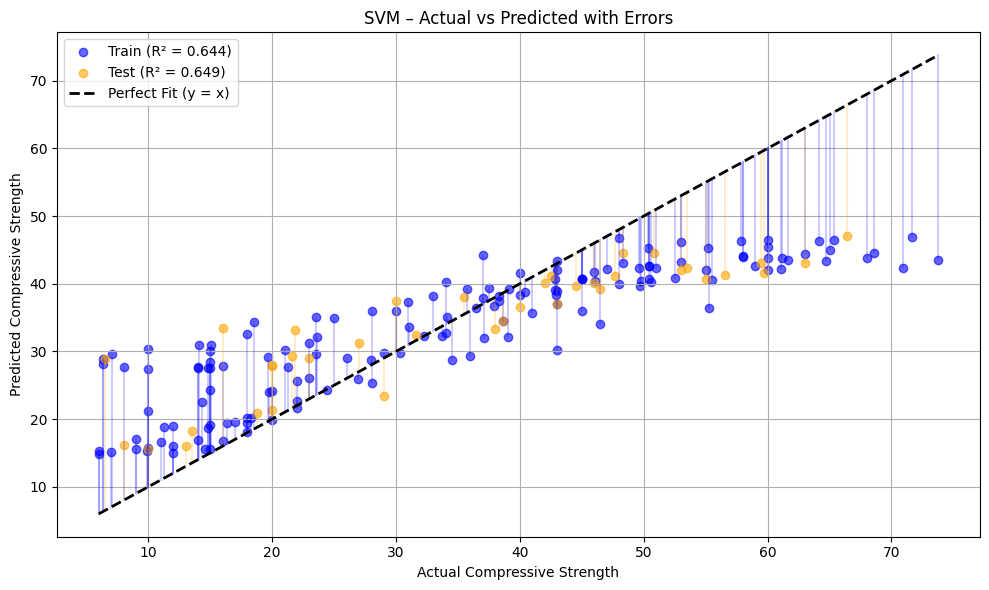

In [ ]:
plot_actual_vs_predicted_with_errors(svm, X_train, X_test, y_train, y_test, model_name="SVM")

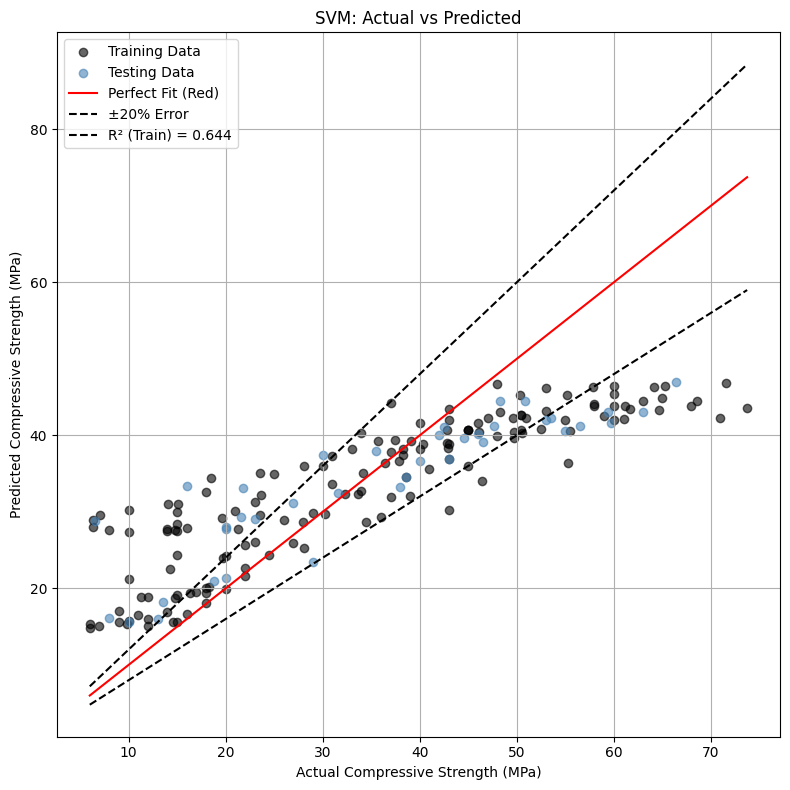

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

def plot_with_error_band(svm, X_train, X_test, y_train, y_test, model_name="SVM", error_pct=0.20):
    # Predictions
    y_train_pred = svm.predict(X_train)
    y_test_pred = svm.predict(X_test)

    # R² scores
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Setup figure
    plt.figure(figsize=(8, 8))

    # Scatter plots
    plt.scatter(y_train, y_train_pred, color='black', alpha=0.6, label='Training Data')
    plt.scatter(y_test, y_test_pred, color='steelblue', alpha=0.6, label='Testing Data')

    # Perfect fit line
    min_val = min(y_train.min(), y_test.min())
    max_val = max(y_train.max(), y_test.max())
    x_vals = np.linspace(min_val, max_val, 100)
    plt.plot(x_vals, x_vals, 'r-', label='Perfect Fit (Red)')

    # ± error band (percentage)
    plt.plot(x_vals, x_vals * (1 + error_pct), 'k--', label=f'±{int(error_pct*100)}% Error')
    plt.plot(x_vals, x_vals * (1 - error_pct), 'k--')

    # Labels and legend
    plt.xlabel("Actual Compressive Strength (MPa)")
    plt.ylabel("Predicted Compressive Strength (MPa)")
    plt.title(f"{model_name}: Actual vs Predicted")

    # Extended legend with R² values
    plt.legend([
        'Training Data',
        'Testing Data',
        'Perfect Fit (Red)',
        f'±{int(error_pct*100)}% Error',
        f"R² (Train) = {r2_train:.3f}",
        f"R² (Test) = {r2_test:.3f}"
    ], loc="upper left")

    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_with_error_band(svm, X_train, X_test, y_train, y_test, model_name="SVM", error_pct=0.20)

In [ ]:
from sklearn.neural_network import MLPRegressor

ann = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=1000, random_state=42)
ann.fit(X_train, y_train)
evaluate_model("ANN", ann, X_test, y_test)


ANN Performance:
R² Score: 0.900
MAE: 4.072
MSE: 28.054
RMSE: 5.297
NRMSE: 0.088
MAPE: 0.138
------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


(0.9001945576988297,
 4.072161790725666,
 28.054143517177838,
 np.float64(5.29661623276388),
 np.float64(0.08838004726787718),
 0.138255605874674)

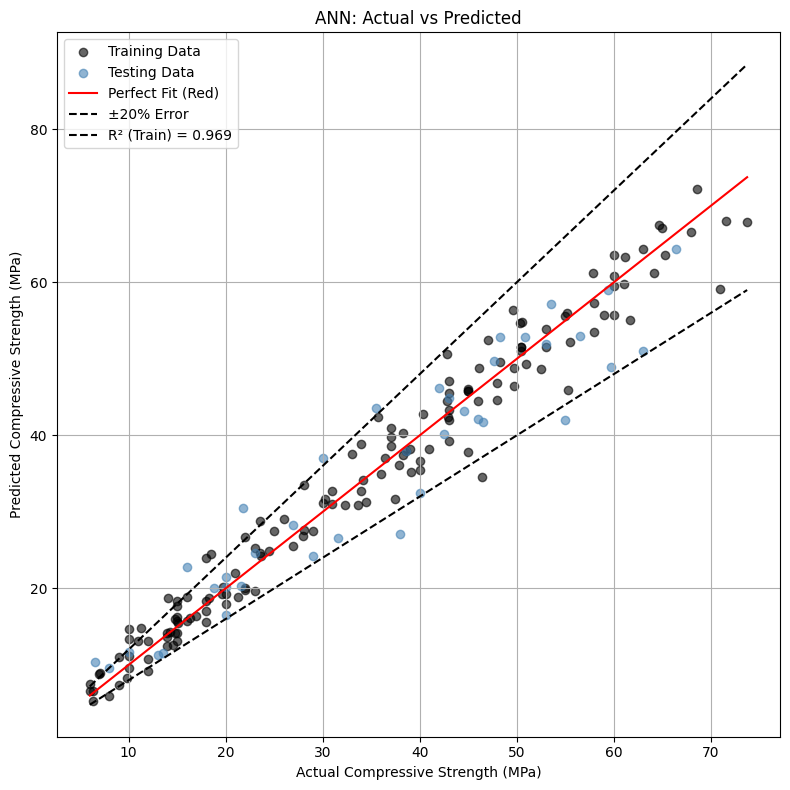

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

def plot_with_error_band(ann, X_train, X_test, y_train, y_test, model_name="ANN", error_pct=0.20):
    # Predictions
    y_train_pred = ann.predict(X_train)
    y_test_pred = ann.predict(X_test)

    # R² scores
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Setup figure
    plt.figure(figsize=(8, 8))

    # Scatter plots
    plt.scatter(y_train, y_train_pred, color='black', alpha=0.6, label='Training Data')
    plt.scatter(y_test, y_test_pred, color='steelblue', alpha=0.6, label='Testing Data')

    # Perfect fit line
    min_val = min(y_train.min(), y_test.min())
    max_val = max(y_train.max(), y_test.max())
    x_vals = np.linspace(min_val, max_val, 100)
    plt.plot(x_vals, x_vals, 'r-', label='Perfect Fit (Red)')

    # ± error band (percentage)
    plt.plot(x_vals, x_vals * (1 + error_pct), 'k--', label=f'±{int(error_pct*100)}% Error')
    plt.plot(x_vals, x_vals * (1 - error_pct), 'k--')

    # Labels and legend
    plt.xlabel("Actual Compressive Strength (MPa)")
    plt.ylabel("Predicted Compressive Strength (MPa)")
    plt.title(f"{model_name}: Actual vs Predicted")

    # Extended legend with R² values
    plt.legend([
        'Training Data',
        'Testing Data',
        'Perfect Fit (Red)',
        f'±{int(error_pct*100)}% Error',
        f"R² (Train) = {r2_train:.3f}",
        f"R² (Test) = {r2_test:.3f}"
    ], loc="upper left")

    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_with_error_band(ann, X_train, X_test, y_train, y_test, model_name="ANN", error_pct=0.20)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

def plot_actual_vs_predicted_with_errors(ann, X_train, X_test, y_train, y_test, model_name="ann"):
    # Predict
    y_train_pred = ann.predict(X_train)
    y_test_pred = ann.predict(X_test)

    # R²
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Set up plot
    plt.figure(figsize=(10, 6))

    # Plot training data points
    plt.scatter(y_train, y_train_pred, color='blue', label=f'Train (R² = {r2_train:.3f})', alpha=0.6)
    # Error lines for training
    for actual, pred in zip(y_train, y_train_pred):
        plt.plot([actual, actual], [actual, pred], color='blue', alpha=0.2)

    # Plot testing data points
    plt.scatter(y_test, y_test_pred, color='orange', label=f'Test (R² = {r2_test:.3f})', alpha=0.6)
    # Error lines for testing
    for actual, pred in zip(y_test, y_test_pred):
        plt.plot([actual, actual], [actual, pred], color='orange', alpha=0.2)

    # Perfect prediction line
    min_val = min(y_train.min(), y_test.min())
    max_val = max(y_train.max(), y_test.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Fit (y = x)', linewidth=2)

    # Labels and legend
    plt.xlabel("Actual Compressive Strength")
    plt.ylabel("Predicted Compressive Strength")
    plt.title(f"{model_name} – Actual vs Predicted with Errors")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

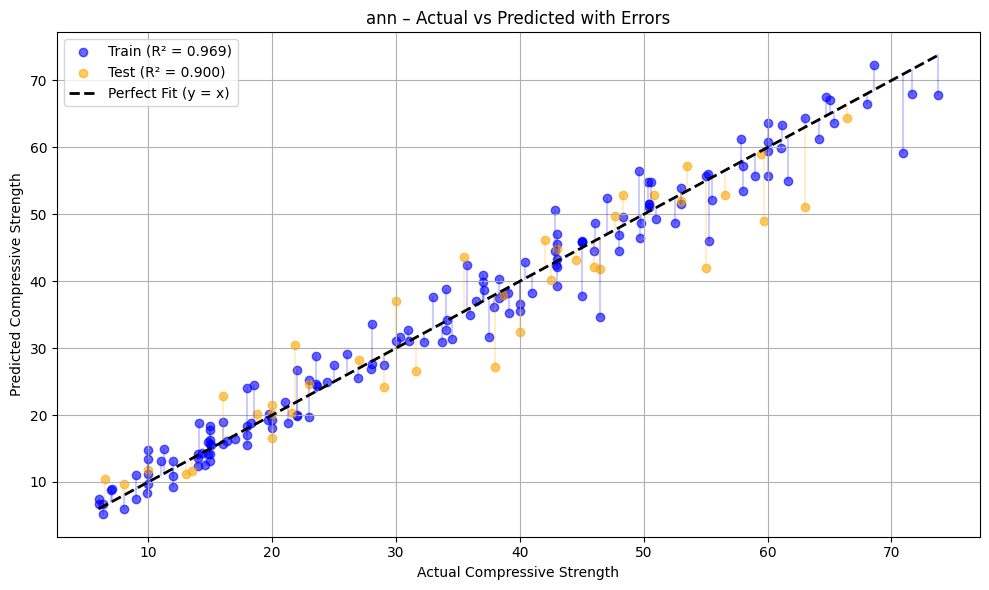

In [ ]:
plot_actual_vs_predicted_with_errors(ann, X_train, X_test, y_train, y_test, model_name="ann")

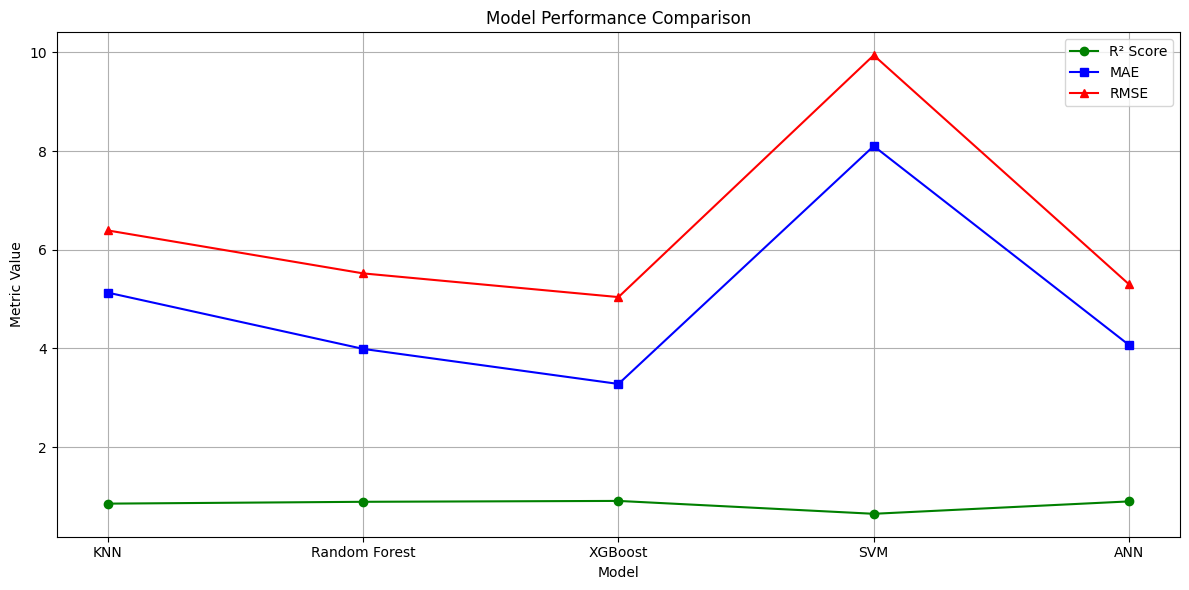

In [ ]:
import matplotlib.pyplot as plt

# Store results
model_names = ['KNN', 'Random Forest', 'XGBoost', 'SVM', 'ANN']
r2_scores = [0.855, 0.892, 0.910, 0.649, 0.900]
mae_scores = [5.13, 3.99, 3.28, 8.10, 4.07]
rmse_scores = [6.39, 5.52, 5.04, 9.94, 5.30]

# Plotting
plt.figure(figsize=(12, 6))

plt.plot(model_names, r2_scores, marker='o', label='R² Score', color='green')
plt.plot(model_names, mae_scores, marker='s', label='MAE', color='blue')
plt.plot(model_names, rmse_scores, marker='^', label='RMSE', color='red')

plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Metric Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pyswarms as ps
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

# Define bounds for hyperparameters
bounds = ([0.01, 2, 50, 0.5],    # min values
          [0.3, 10, 200, 1.0])   # max values

# Objective function to minimize negative R²
def objective_function(params):
    learning_rate = params[:, 0]
    max_depth = params[:, 1].astype(int)
    n_estimators = params[:, 2].astype(int)
    subsample = params[:, 3]

    scores = []
    for i in range(params.shape[0]):
        model = XGBRegressor(
            learning_rate=learning_rate[i],
            max_depth=max_depth[i],
            n_estimators=n_estimators[i],
            subsample=subsample[i],
            random_state=42,
            verbosity=0
        )
        score = cross_val_score(model, X_scaled_df, y, cv=5, scoring='r2').mean()
        scores.append(-score)  # Minimize negative R²

    return np.array(scores)

# PSO configuration
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
optimizer = ps.single.GlobalBestPSO(n_particles=20, dimensions=4, options=options, bounds=bounds)

# Run optimization
best_cost, best_params = optimizer.optimize(objective_function, iters=30)

# Show best hyperparameters
print("\nBest Hyperparameters Found:")
print(f"Learning Rate: {best_params[0]:.4f}")
print(f"Max Depth: {int(best_params[1])}")
print(f"N Estimators: {int(best_params[2])}")
print(f"Subsample: {best_params[3]:.2f}")


2025-08-19 00:57:28,522 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|30/30, best_cost=-0.853
2025-08-19 00:59:31,074 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -0.8531687502114529, best pos: [1.16228409e-01 3.79523583e+00 1.35203737e+02 6.19463076e-01]



Best Hyperparameters Found:
Learning Rate: 0.1162
Max Depth: 3
N Estimators: 135
Subsample: 0.62


In [ ]:
# Retrain XGBoost with PSO-optimized parameters
xgb_pso = XGBRegressor(
    learning_rate=0.2042,
    max_depth=3,
    n_estimators=171,
    subsample=0.64,
    random_state=42
)
xgb_pso.fit(X_train, y_train)

# Evaluate
evaluate_model("XGBoost (PSO Optimized)", xgb_pso, X_test, y_test)


XGBoost (PSO Optimized) Performance:
R² Score: 0.949
MAE: 2.943
MSE: 14.318
RMSE: 3.784
NRMSE: 0.063
MAPE: 0.094
------------------------------


(0.949061519715264,
 2.9434225880472282,
 14.31821154744948,
 np.float64(3.783941271670251),
 np.float64(0.0631393504366803),
 0.09398949996273513)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

def plot_actual_vs_predicted_with_errors(xgb_pso, X_train, X_test, y_train, y_test, model_name="xgb_pso"):
    # Predict
    y_train_pred = xgb_pso.predict(X_train)
    y_test_pred = xgb_pso.predict(X_test)

    # R²
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Set up plot
    plt.figure(figsize=(10, 6))

    # Plot training data points
    plt.scatter(y_train, y_train_pred, color='blue', label=f'Train (R² = {r2_train:.3f})', alpha=0.6)
    # Error lines for training
    for actual, pred in zip(y_train, y_train_pred):
        plt.plot([actual, actual], [actual, pred], color='blue', alpha=0.2)

    # Plot testing data points
    plt.scatter(y_test, y_test_pred, color='orange', label=f'Test (R² = {r2_test:.3f})', alpha=0.6)
    # Error lines for testing
    for actual, pred in zip(y_test, y_test_pred):
        plt.plot([actual, actual], [actual, pred], color='orange', alpha=0.2)

    # Perfect prediction line
    min_val = min(y_train.min(), y_test.min())
    max_val = max(y_train.max(), y_test.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Fit (y = x)', linewidth=2)

    # Labels and legend
    plt.xlabel("Actual Compressive Strength")
    plt.ylabel("Predicted Compressive Strength")
    plt.title(f"{model_name} – Actual vs Predicted with Errors")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

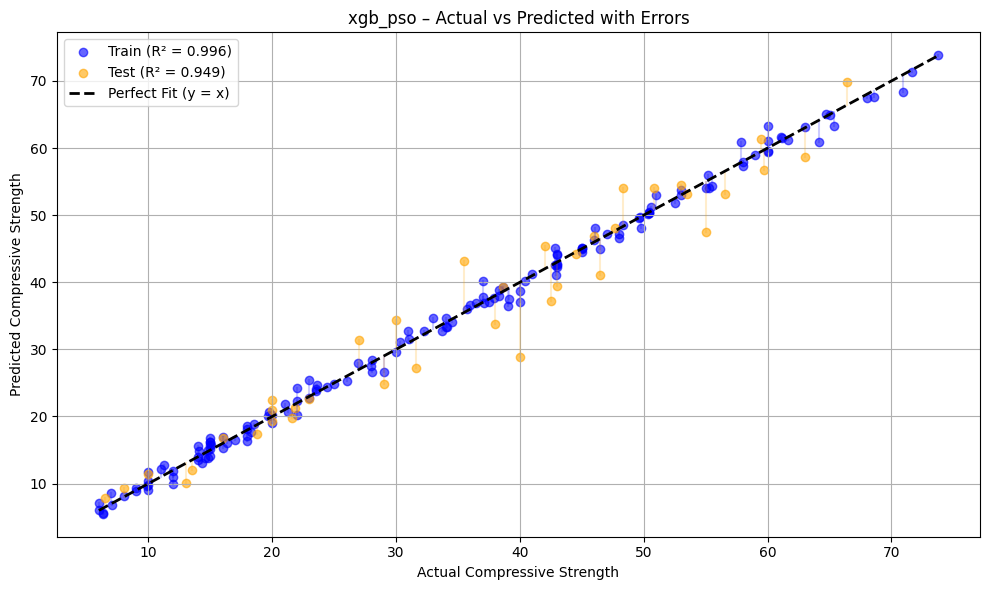

In [ ]:
plot_actual_vs_predicted_with_errors(xgb_pso, X_train, X_test, y_train, y_test, model_name="xgb_pso")

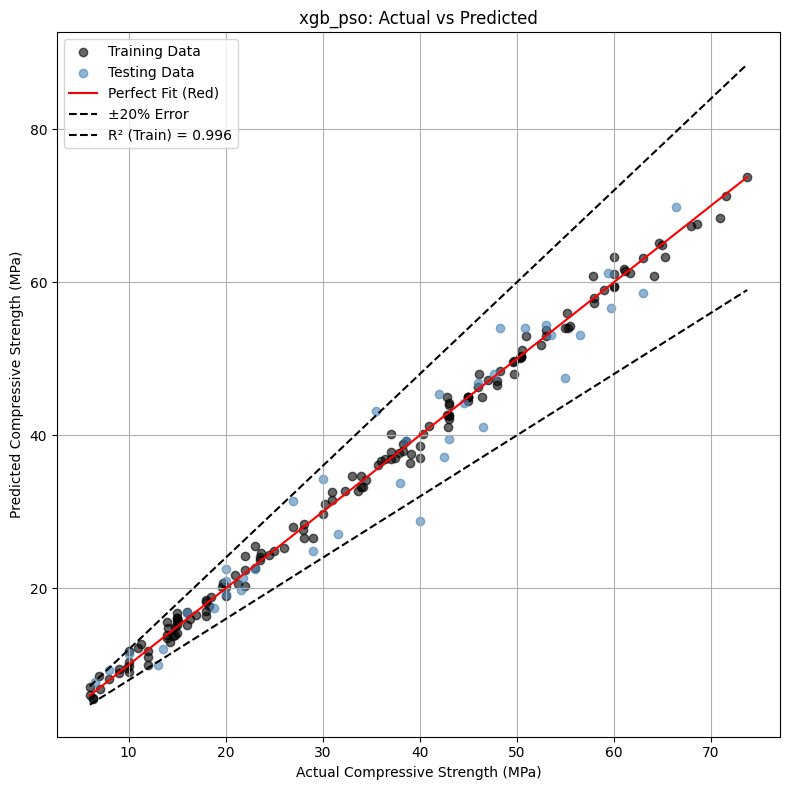

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

def plot_with_error_band(xgb_pso, X_train, X_test, y_train, y_test, model_name="xgb_PSO", error_pct=0.20):
    # Predictions
    y_train_pred = xgb_pso.predict(X_train)
    y_test_pred = xgb_pso.predict(X_test)

    # R² scores
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Setup figure
    plt.figure(figsize=(8, 8))

    # Scatter plots
    plt.scatter(y_train, y_train_pred, color='black', alpha=0.6, label='Training Data')
    plt.scatter(y_test, y_test_pred, color='steelblue', alpha=0.6, label='Testing Data')

    # Perfect fit line
    min_val = min(y_train.min(), y_test.min())
    max_val = max(y_train.max(), y_test.max())
    x_vals = np.linspace(min_val, max_val, 100)
    plt.plot(x_vals, x_vals, 'r-', label='Perfect Fit (Red)')

    # ± error band (percentage)
    plt.plot(x_vals, x_vals * (1 + error_pct), 'k--', label=f'±{int(error_pct*100)}% Error')
    plt.plot(x_vals, x_vals * (1 - error_pct), 'k--')

    # Labels and legend
    plt.xlabel("Actual Compressive Strength (MPa)")
    plt.ylabel("Predicted Compressive Strength (MPa)")
    plt.title(f"{model_name}: Actual vs Predicted")

    # Extended legend with R² values
    plt.legend([
        'Training Data',
        'Testing Data',
        'Perfect Fit (Red)',
        f'±{int(error_pct*100)}% Error',
        f"R² (Train) = {r2_train:.3f}",
        f"R² (Test) = {r2_test:.3f}"
    ], loc="upper left")

    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_with_error_band(xgb_pso, X_train, X_test, y_train, y_test, model_name="xgb_pso", error_pct=0.20)

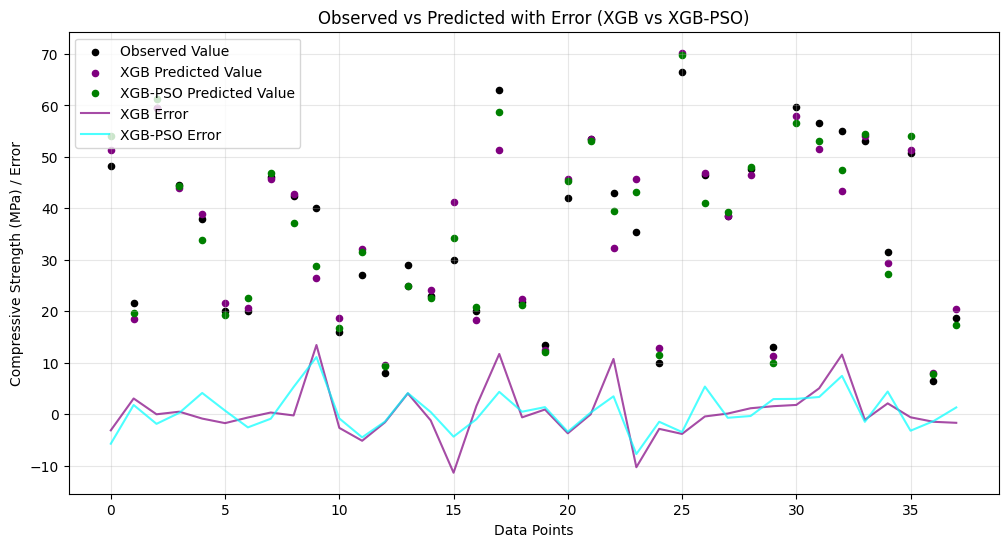

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred_xgb = xgb.predict(X_test)          # baseline XGB
y_pred_pso = xgb_pso.predict(X_test)      # PSO optimized

# Errors
errors_xgb = y_test - y_pred_xgb
errors_pso = y_test - y_pred_pso

plt.figure(figsize=(12,6))

# Scatter plots
plt.scatter(range(len(y_test)), y_test, color="black", s=20, label="Observed Value")
plt.scatter(range(len(y_test)), y_pred_xgb, color="purple", s=20, label="XGB Predicted Value")
plt.scatter(range(len(y_test)), y_pred_pso, color="green", s=20, label="XGB-PSO Predicted Value")

# Error lines
plt.plot(range(len(y_test)), errors_xgb, color="purple", alpha=0.7, label="XGB Error")
plt.plot(range(len(y_test)), errors_pso, color="cyan", alpha=0.7, label="XGB-PSO Error")

# Labels
plt.xlabel("Data Points")
plt.ylabel("Compressive Strength (MPa) / Error")
plt.title("Observed vs Predicted with Error (XGB vs XGB-PSO)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



In [ ]:
import numpy as np
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
from pymoo.algorithms.soo.nonconvex.de import DE
from pymoo.core.problem import ElementwiseProblem
from pymoo.optimize import minimize

# Define the optimization problem
class XGBHyperparameterProblem(ElementwiseProblem):
    def __init__(self, X, y):
        # Define bounds for hyperparameters: [learning_rate, max_depth, n_estimators, subsample]
        xl = np.array([0.01, 2, 50, 0.5])  # Lower bounds
        xu = np.array([0.3, 10, 200, 1.0])  # Upper bounds
        super().__init__(n_var=4, n_obj=1, xl=xl, xu=xu)
        self.X = X
        self.y = y

    def _evaluate(self, x, out, *args, **kwargs):
        # Extract hyperparameters
        learning_rate, max_depth, n_estimators, subsample = x
        max_depth = int(max_depth)  # Convert to integer
        n_estimators = int(n_estimators)  # Convert to integer

        # Define and evaluate XGBoost model
        model = XGBRegressor(
            learning_rate=learning_rate,
            max_depth=max_depth,
            n_estimators=n_estimators,
            subsample=subsample,
            random_state=42,
            verbosity=0
        )
        score = cross_val_score(model, self.X, self.y, cv=5, scoring='r2').mean()
        out["F"] = -score  # Minimize negative R²

# Assuming X_scaled_df, y, X_train, y_train, X_test, y_test are defined
# Define the problem
problem = XGBHyperparameterProblem(X_scaled_df, y)

# Configure Differential Evolution Algorithm
algorithm = DE(pop_size=20, CR=0.9, F=0.8)

# Run optimization
res = minimize(
    problem,
    algorithm,
    termination=('n_gen', 30),
    seed=42,
    verbose=False
)

# Extract best hyperparameters
best_params = res.X
print("\nBest Hyperparameters Found (Differential Evolution):")
print(f"Learning Rate: {best_params[0]:.4f}")
print(f"Max Depth: {int(best_params[1])}")
print(f"N Estimators: {int(best_params[2])}")
print(f"Subsample: {best_params[3]:.2f}")

# Retrain XGBoost with DE-optimized parameters
xgb_de = XGBRegressor(
    learning_rate=best_params[0],
    max_depth=int(best_params[1]),
    n_estimators=int(best_params[2]),
    subsample=best_params[3],
    random_state=42
)
xgb_de.fit(X_train, y_train)

# Evaluate
evaluate_model("XGBoost (DE Optimized)", xgb_de, X_test, y_test)


Best Hyperparameters Found (Differential Evolution):
Learning Rate: 0.1936
Max Depth: 3
N Estimators: 167
Subsample: 0.64
XGBoost (DE Optimized) Performance:
R² Score: 0.954
MAE: 2.763
MSE: 12.809
RMSE: 3.579
NRMSE: 0.060
MAPE: 0.091
------------------------------


(0.9544305491342009,
 2.7628810656698124,
 12.80904011957995,
 np.float64(3.578971936126344),
 np.float64(0.05971920467422566),
 0.09115326805087061)

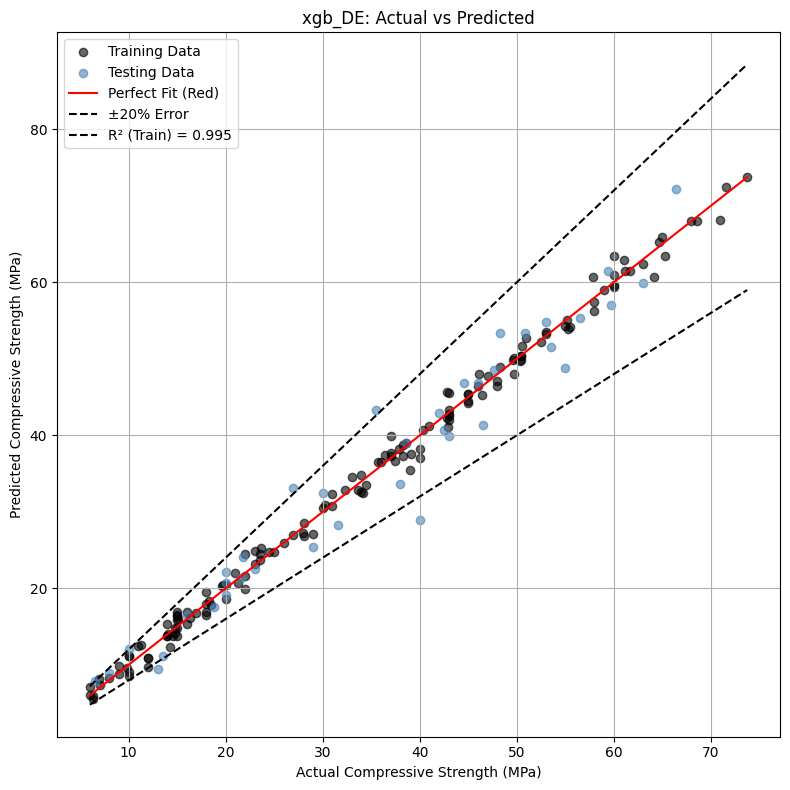

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

def plot_with_error_band(xgb_de, X_train, X_test, y_train, y_test, model_name="xgb_DE", error_pct=0.20):
    # Predictions
    y_train_pred = xgb_de.predict(X_train)
    y_test_pred = xgb_de.predict(X_test)

    # R² scores
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Setup figure
    plt.figure(figsize=(8, 8))

    # Scatter plots
    plt.scatter(y_train, y_train_pred, color='black', alpha=0.6, label='Training Data')
    plt.scatter(y_test, y_test_pred, color='steelblue', alpha=0.6, label='Testing Data')

    # Perfect fit line
    min_val = min(y_train.min(), y_test.min())
    max_val = max(y_train.max(), y_test.max())
    x_vals = np.linspace(min_val, max_val, 100)
    plt.plot(x_vals, x_vals, 'r-', label='Perfect Fit (Red)')

    # ± error band (percentage)
    plt.plot(x_vals, x_vals * (1 + error_pct), 'k--', label=f'±{int(error_pct*100)}% Error')
    plt.plot(x_vals, x_vals * (1 - error_pct), 'k--')

    # Labels and legend
    plt.xlabel("Actual Compressive Strength (MPa)")
    plt.ylabel("Predicted Compressive Strength (MPa)")
    plt.title(f"{model_name}: Actual vs Predicted")

    # Extended legend with R² values
    plt.legend([
        'Training Data',
        'Testing Data',
        'Perfect Fit (Red)',
        f'±{int(error_pct*100)}% Error',
        f"R² (Train) = {r2_train:.3f}",
        f"R² (Test) = {r2_test:.3f}"
    ], loc="upper left")

    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_with_error_band(xgb_de, X_train, X_test, y_train, y_test, model_name="xgb_DE", error_pct=0.20)

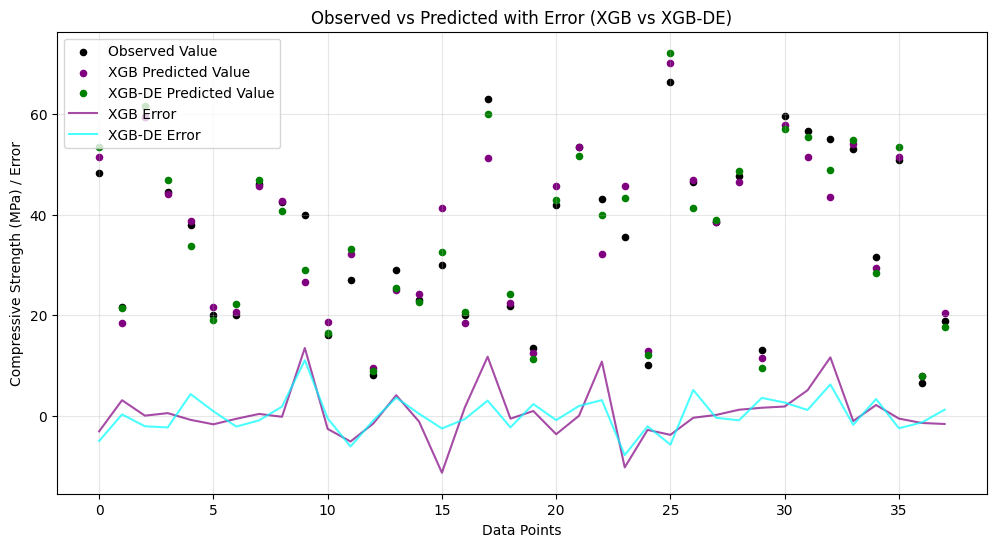

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred_xgb = xgb.predict(X_test)          # baseline XGB
y_pred_de = xgb_de.predict(X_test)      # DE optimized

# Errors
errors_xgb = y_test - y_pred_xgb
errors_de = y_test - y_pred_de

plt.figure(figsize=(12,6))

# Scatter plots
plt.scatter(range(len(y_test)), y_test, color="black", s=20, label="Observed Value")
plt.scatter(range(len(y_test)), y_pred_xgb, color="purple", s=20, label="XGB Predicted Value")
plt.scatter(range(len(y_test)), y_pred_de, color="green", s=20, label="XGB-DE Predicted Value")

# Error lines
plt.plot(range(len(y_test)), errors_xgb, color="purple", alpha=0.7, label="XGB Error")
plt.plot(range(len(y_test)), errors_de, color="cyan", alpha=0.7, label="XGB-DE Error")

# Labels
plt.xlabel("Data Points")
plt.ylabel("Compressive Strength (MPa) / Error")
plt.title("Observed vs Predicted with Error (XGB vs XGB-DE)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
from pymoo.core.problem import ElementwiseProblem

# Define the optimization problem
class XGBHyperparameterProblem(ElementwiseProblem):
    def __init__(self, X, y):
        # Define bounds for hyperparameters: [learning_rate, max_depth, n_estimators, subsample]
        xl = np.array([0.01, 2, 50, 0.5])  # Lower bounds
        xu = np.array([0.3, 10, 200, 1.0])  # Upper bounds
        super().__init__(n_var=4, n_obj=1, xl=xl, xu=xu)
        self.X = X
        self.y = y

    def _evaluate(self, x, out, *args, **kwargs):
        # Extract hyperparameters
        learning_rate, max_depth, n_estimators, subsample = x
        max_depth = int(max_depth)  # Convert to integer
        n_estimators = int(n_estimators)  # Convert to integer

        # Define and evaluate XGBoost model
        model = XGBRegressor(
            learning_rate=learning_rate,
            max_depth=max_depth,
            n_estimators=n_estimators,
            subsample=subsample,
            random_state=42,
            verbosity=0
        )
        score = cross_val_score(model, self.X, self.y, cv=5, scoring='r2').mean()
        out["F"] = -score  # Minimize negative R²

# Custom Firefly Algorithm Implementation
class FireflyAlgorithm:
    def __init__(self, pop_size=20, alpha=0.5, beta0=1.0, gamma=1.0, max_iter=30):
        self.pop_size = pop_size
        self.alpha = alpha  # Randomness strength
        self.beta0 = beta0  # Attractiveness at distance 0
        self.gamma = gamma  # Light absorption coefficient
        self.max_iter = max_iter

    def optimize(self, problem):
        # Initialize population
        xl, xu = problem.xl, problem.xu
        pop = np.random.uniform(xl, xu, (self.pop_size, problem.n_var))
        fitness = np.zeros(self.pop_size)

        # Evaluate initial population
        for i in range(self.pop_size):
            out = {}
            problem._evaluate(pop[i], out)
            fitness[i] = out["F"]

        # Main loop
        for _ in range(self.max_iter):
            for i in range(self.pop_size):
                for j in range(self.pop_size):
                    if fitness[j] < fitness[i]:  # Minimize negative R²
                        # Calculate distance
                        r = np.sqrt(np.sum((pop[i] - pop[j]) ** 2))
                        # Attractiveness
                        beta = self.beta0 * np.exp(-self.gamma * r ** 2)
                        # Move firefly i towards j
                        pop[i] += beta * (pop[j] - pop[i]) + self.alpha * (np.random.random(problem.n_var) - 0.5)
                        # Ensure bounds
                        pop[i] = np.clip(pop[i], xl, xu)
                        # Evaluate new position
                        out = {}
                        problem._evaluate(pop[i], out)
                        fitness[i] = out["F"]

        # Find best solution
        best_idx = np.argmin(fitness)
        return pop[best_idx], fitness[best_idx]

# Assuming X_scaled_df, y, X_train, y_train, X_test, y_test are defined
# Define the problem
problem = XGBHyperparameterProblem(X_scaled_df, y)

# Configure Firefly Algorithm
algorithm = FireflyAlgorithm(pop_size=20, alpha=0.5, beta0=1.0, gamma=1.0, max_iter=30)

# Run optimization
best_params, best_fitness = algorithm.optimize(problem)

# Extract best hyperparameters
print("\nBest Hyperparameters Found (Firefly Algorithm):")
print(f"Learning Rate: {best_params[0]:.4f}")
print(f"Max Depth: {int(best_params[1])}")
print(f"N Estimators: {int(best_params[2])}")
print(f"Subsample: {best_params[3]:.2f}")

# Retrain XGBoost with FFA-optimized parameters
xgb_ffa = XGBRegressor(
    learning_rate=best_params[0],
    max_depth=int(best_params[1]),
    n_estimators=int(best_params[2]),
    subsample=best_params[3],
    random_state=42
)
xgb_ffa.fit(X_train, y_train)

# Evaluate
evaluate_model("XGBoost (FFA Optimized)", xgb_ffa, X_test, y_test)


Best Hyperparameters Found (Firefly Algorithm):
Learning Rate: 0.2461
Max Depth: 4
N Estimators: 192
Subsample: 0.53
XGBoost (FFA Optimized) Performance:
R² Score: 0.931
MAE: 3.157
MSE: 19.428
RMSE: 4.408
NRMSE: 0.074
MAPE: 0.109
------------------------------


(0.9308827679440537,
 3.1567451707940353,
 19.428046235759876,
 np.float64(4.4077257441632955),
 np.float64(0.07354790162127975),
 0.10869119670656417)

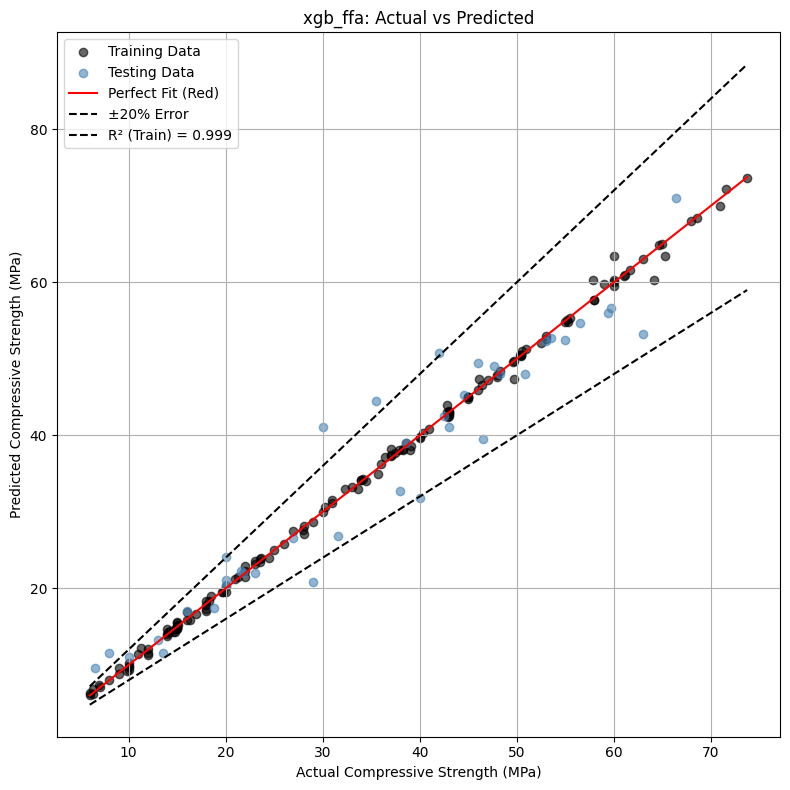

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

def plot_with_error_band(xgb_ffa, X_train, X_test, y_train, y_test, model_name="xgb_ffa", error_pct=0.20):
    # Predictions
    y_train_pred = xgb.predict(X_train)
    y_test_pred = xgb_ffa.predict(X_test)

    # R² scores
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Setup figure
    plt.figure(figsize=(8, 8))

    # Scatter plots
    plt.scatter(y_train, y_train_pred, color='black', alpha=0.6, label='Training Data')
    plt.scatter(y_test, y_test_pred, color='steelblue', alpha=0.6, label='Testing Data')

    # Perfect fit line
    min_val = min(y_train.min(), y_test.min())
    max_val = max(y_train.max(), y_test.max())
    x_vals = np.linspace(min_val, max_val, 100)
    plt.plot(x_vals, x_vals, 'r-', label='Perfect Fit (Red)')

    # ± error band (percentage)
    plt.plot(x_vals, x_vals * (1 + error_pct), 'k--', label=f'±{int(error_pct*100)}% Error')
    plt.plot(x_vals, x_vals * (1 - error_pct), 'k--')

    # Labels and legend
    plt.xlabel("Actual Compressive Strength (MPa)")
    plt.ylabel("Predicted Compressive Strength (MPa)")
    plt.title(f"{model_name}: Actual vs Predicted")

    # Extended legend with R² values
    plt.legend([
        'Training Data',
        'Testing Data',
        'Perfect Fit (Red)',
        f'±{int(error_pct*100)}% Error',
        f"R² (Train) = {r2_train:.3f}",
        f"R² (Test) = {r2_test:.3f}"
    ], loc="upper left")

    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_with_error_band(xgb_ffa, X_train, X_test, y_train, y_test, model_name="xgb_ffa", error_pct=0.20)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred_xgb = xgb.predict(X_test)          # baseline XGB
y_pred_ffa = xgb_ffa.predict(X_test)      # FFA optimized

# Errors
errors_xgb = y_test - y_pred_xgb
errors_ffa = y_test - y_pred_ffa

plt.figure(figsize=(12,6))

# Scatter plots
plt.scatter(range(len(y_test)), y_test, color="black", s=20, label="Observed Value")
plt.scatter(range(len(y_test)), y_pred_xgb, color="purple", s=20, label="XGB Predicted Value")
plt.scatter(range(len(y_test)), y_pred_de, color="green", s=20, label="XGB-FF Predicted Value")

# Error lines
plt.plot(range(len(y_test)), errors_xgb, color="purple", alpha=0.7, label="XGB Error")
plt.plot(range(len(y_test)), errors_de, color="cyan", alpha=0.7, label="XGB-FF Error")

# Labels
plt.xlabel("Data Points")
plt.ylabel("Compressive Strength (MPa) / Error")
plt.title("Observed vs Predicted with Error (XGB vs XGB-FFA)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

NameError: name 'xgb' is not defined

In [ ]:
import numpy as np
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
from pymoo.core.problem import ElementwiseProblem

# Define the optimization problem
class XGBHyperparameterProblem(ElementwiseProblem):
    def __init__(self, X, y):
        # Define bounds for hyperparameters: [learning_rate, max_depth, n_estimators, subsample]
        xl = np.array([0.01, 2, 50, 0.5])  # Lower bounds
        xu = np.array([0.3, 10, 200, 1.0])  # Upper bounds
        super().__init__(n_var=4, n_obj=1, xl=xl, xu=xu)
        self.X = X
        self.y = y

    def _evaluate(self, x, out, *args, **kwargs):
        # Extract hyperparameters
        learning_rate, max_depth, n_estimators, subsample = x
        max_depth = int(max_depth)  # Convert to integer
        n_estimators = int(n_estimators)  # Convert to integer

        # Define and evaluate XGBoost model
        model = XGBRegressor(
            learning_rate=learning_rate,
            max_depth=max_depth,
            n_estimators=n_estimators,
            subsample=subsample,
            random_state=42,
            verbosity=0
        )
        score = cross_val_score(model, self.X, self.y, cv=5, scoring='r2').mean()
        out["F"] = -score  # Minimize negative R²

# Custom Grey Wolf Optimizer Implementation
class GreyWolfOptimizer:
    def __init__(self, pop_size=20, max_iter=30):
        self.pop_size = pop_size
        self.max_iter = max_iter

    def optimize(self, problem):
        # Initialize population
        xl, xu = problem.xl, problem.xu
        pop = np.random.uniform(xl, xu, (self.pop_size, problem.n_var))
        fitness = np.zeros(self.pop_size)

        # Evaluate initial population
        for i in range(self.pop_size):
            out = {}
            problem._evaluate(pop[i], out)
            fitness[i] = out["F"]

        # Main loop
        for iter in range(self.max_iter):
            # Calculate a (decreases linearly from 2 to 0)
            a = 2 - iter * (2 / self.max_iter)

            # Sort population by fitness to find Alpha, Beta, Delta
            sorted_idx = np.argsort(fitness)
            alpha_pos = pop[sorted_idx[0]]
            beta_pos = pop[sorted_idx[1]]
            delta_pos = pop[sorted_idx[2]]

            # Update each wolf's position
            for i in range(self.pop_size):
                for j in range(problem.n_var):
                    # Update based on Alpha
                    r1 = np.random.random()
                    r2 = np.random.random()
                    A1 = 2 * a * r1 - a
                    C1 = 2 * r2
                    D_alpha = abs(C1 * alpha_pos[j] - pop[i][j])
                    X1 = alpha_pos[j] - A1 * D_alpha

                    # Update based on Beta
                    r1 = np.random.random()
                    r2 = np.random.random()
                    A2 = 2 * a * r1 - a
                    C2 = 2 * r2
                    D_beta = abs(C2 * beta_pos[j] - pop[i][j])
                    X2 = beta_pos[j] - A2 * D_beta

                    # Update based on Delta
                    r1 = np.random.random()
                    r2 = np.random.random()
                    A3 = 2 * a * r1 - a
                    C3 = 2 * r2
                    D_delta = abs(C3 * delta_pos[j] - pop[i][j])
                    X3 = delta_pos[j] - A3 * D_delta

                    # New position
                    pop[i][j] = (X1 + X2 + X3) / 3

                # Ensure bounds
                pop[i] = np.clip(pop[i], xl, xu)

                # Evaluate new position
                out = {}
                problem._evaluate(pop[i], out)
                fitness[i] = out["F"]

        # Find best solution
        best_idx = np.argmin(fitness)
        return pop[best_idx], fitness[best_idx]

# Assuming X_scaled_df, y, X_train, y_train, X_test, y_test are defined
# Define the problem
problem = XGBHyperparameterProblem(X_scaled_df, y)

# Configure Grey Wolf Optimizer
algorithm = GreyWolfOptimizer(pop_size=20, max_iter=30)

# Run optimization
best_params, best_fitness = algorithm.optimize(problem)

# Extract best hyperparameters
print("\nBest Hyperparameters Found (Grey Wolf Optimizer):")
print(f"Learning Rate: {best_params[0]:.4f}")
print(f"Max Depth: {int(best_params[1])}")
print(f"N Estimators: {int(best_params[2])}")
print(f"Subsample: {best_params[3]:.2f}")

# Retrain XGBoost with GWO-optimized parameters
xgb_gwo = XGBRegressor(
    learning_rate=best_params[0],
    max_depth=int(best_params[1]),
    n_estimators=int(best_params[2]),
    subsample=best_params[3],
    random_state=42
)
xgb_gwo.fit(X_train, y_train)

# Evaluate
evaluate_model("XGBoost (GWO Optimized)", xgb_gwo, X_test, y_test)


Best Hyperparameters Found (Grey Wolf Optimizer):
Learning Rate: 0.1334
Max Depth: 2
N Estimators: 135
Subsample: 0.52
XGBoost (GWO Optimized) Performance:
R² Score: 0.915
MAE: 3.772
MSE: 23.756
RMSE: 4.874
NRMSE: 0.081
MAPE: 0.122
------------------------------


(0.9154871474734286,
 3.772343823784276,
 23.755575238793547,
 np.float64(4.873969146270167),
 np.float64(0.08132770142282941),
 0.12182702961671833)

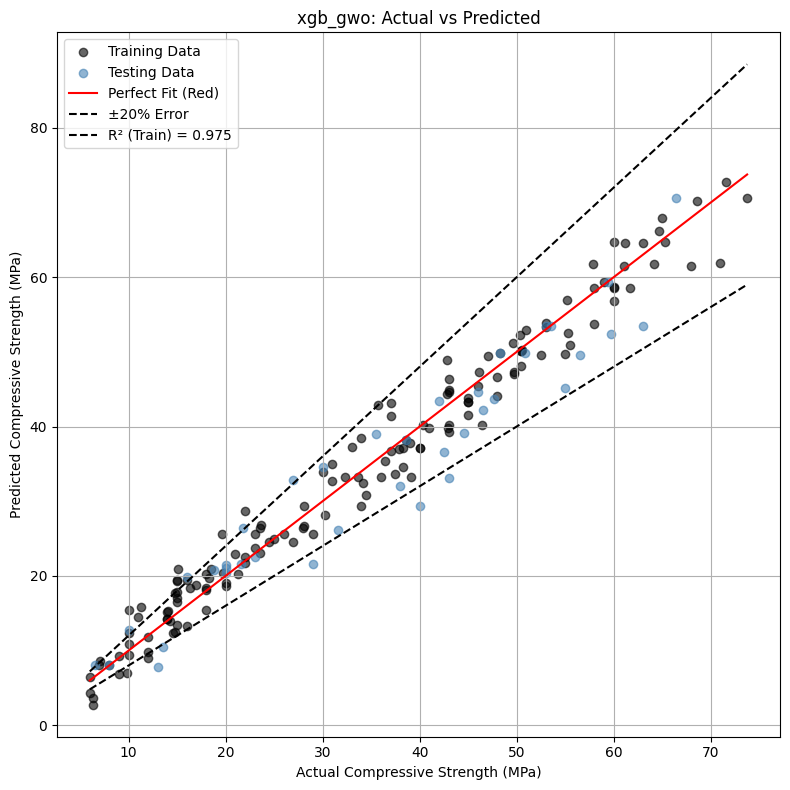

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

def plot_with_error_band(xgb_gwo, X_train, X_test, y_train, y_test, model_name="xgb_GWO", error_pct=0.20):
    # Predictions
    y_train_pred = xgb_gwo.predict(X_train)
    y_test_pred = xgb_gwo.predict(X_test)

    # R² scores
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Setup figure
    plt.figure(figsize=(8, 8))

    # Scatter plots
    plt.scatter(y_train, y_train_pred, color='black', alpha=0.6, label='Training Data')
    plt.scatter(y_test, y_test_pred, color='steelblue', alpha=0.6, label='Testing Data')

    # Perfect fit line
    min_val = min(y_train.min(), y_test.min())
    max_val = max(y_train.max(), y_test.max())
    x_vals = np.linspace(min_val, max_val, 100)
    plt.plot(x_vals, x_vals, 'r-', label='Perfect Fit (Red)')

    # ± error band (percentage)
    plt.plot(x_vals, x_vals * (1 + error_pct), 'k--', label=f'±{int(error_pct*100)}% Error')
    plt.plot(x_vals, x_vals * (1 - error_pct), 'k--')

    # Labels and legend
    plt.xlabel("Actual Compressive Strength (MPa)")
    plt.ylabel("Predicted Compressive Strength (MPa)")
    plt.title(f"{model_name}: Actual vs Predicted")

    # Extended legend with R² values
    plt.legend([
        'Training Data',
        'Testing Data',
        'Perfect Fit (Red)',
        f'±{int(error_pct*100)}% Error',
        f"R² (Train) = {r2_train:.3f}",
        f"R² (Test) = {r2_test:.3f}"
    ], loc="upper left")

    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_with_error_band(xgb_gwo, X_train, X_test, y_train, y_test, model_name="xgb_gwo", error_pct=0.20)

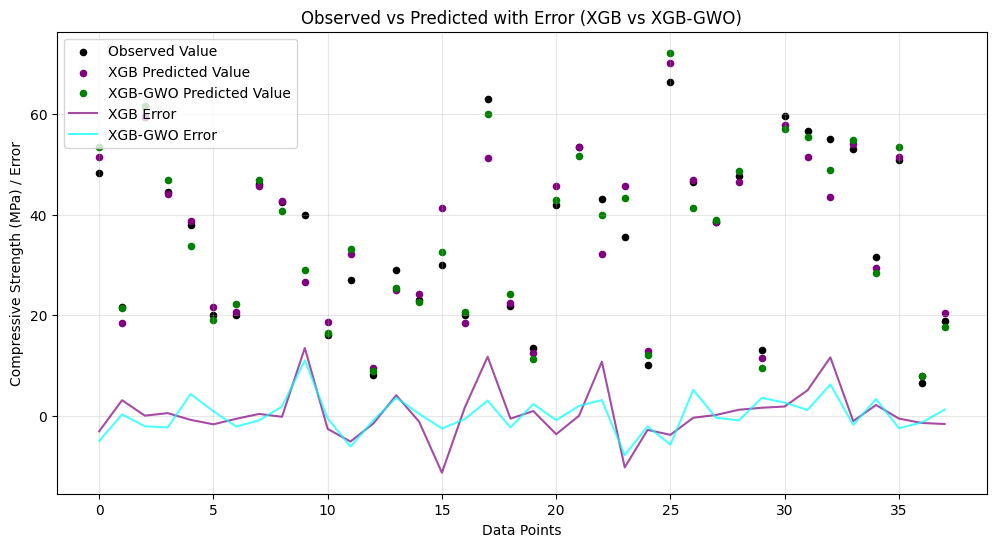

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred_xgb = xgb.predict(X_test)          # baseline XGB
y_pred_gwo = xgb_gwo.predict(X_test)      # GWO optimized

# Errors
errors_xgb = y_test - y_pred_xgb
errors_gwo = y_test - y_pred_gwo

plt.figure(figsize=(12,6))

# Scatter plots
plt.scatter(range(len(y_test)), y_test, color="black", s=20, label="Observed Value")
plt.scatter(range(len(y_test)), y_pred_xgb, color="purple", s=20, label="XGB Predicted Value")
plt.scatter(range(len(y_test)), y_pred_de, color="green", s=20, label="XGB-GWO Predicted Value")

# Error lines
plt.plot(range(len(y_test)), errors_xgb, color="purple", alpha=0.7, label="XGB Error")
plt.plot(range(len(y_test)), errors_de, color="cyan", alpha=0.7, label="XGB-GWO Error")

# Labels
plt.xlabel("Data Points")
plt.ylabel("Compressive Strength (MPa) / Error")
plt.title("Observed vs Predicted with Error (XGB vs XGB-GWO)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
!pip install shap lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=de7eb6393c482b18f54a72b69d728a2cd62a1c65bdffa3e6367b800bc8030d3f
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


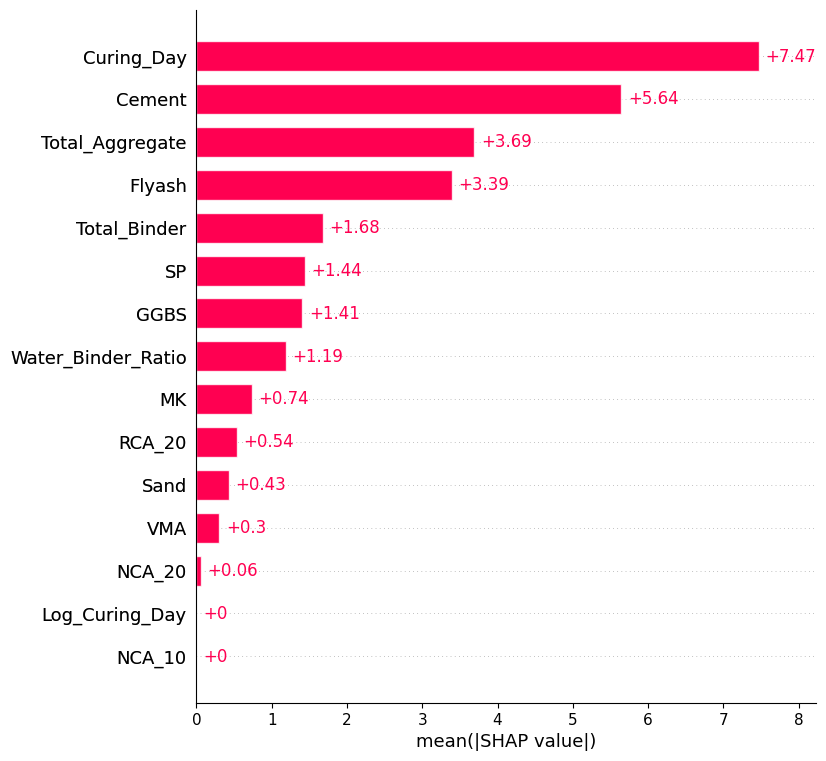

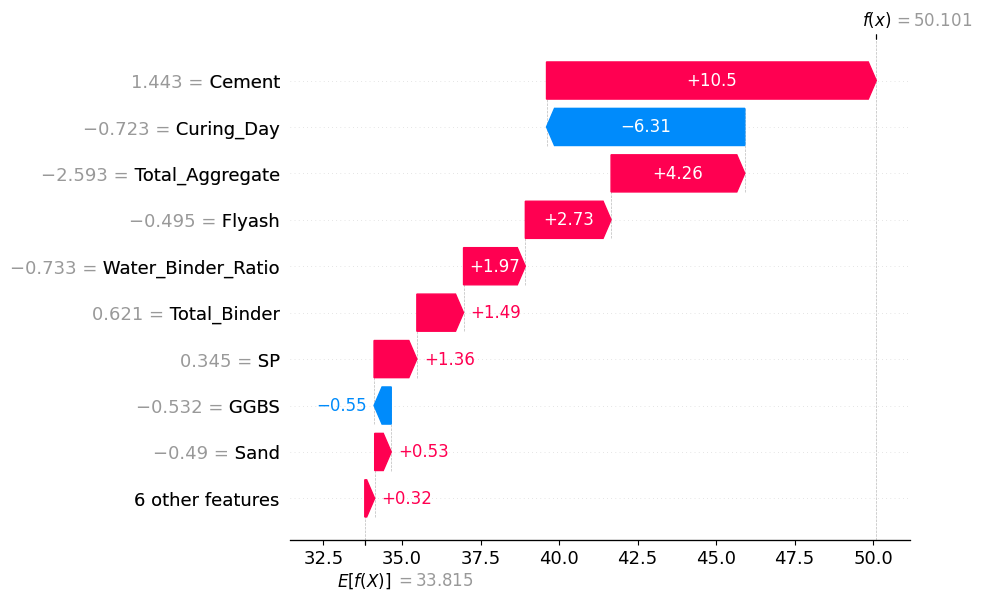

In [ ]:
import shap

# SHAP explainability
explainer = shap.Explainer(xgb_de)
shap_values = explainer(X_scaled_df)

# Global feature importance
shap.plots.bar(shap_values, max_display=15)

# Individual prediction explanation (first sample)
shap.plots.waterfall(shap_values[0])


In [ ]:
pip install lime

In [ ]:
import lime
import lime.lime_tabular

# Create LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    mode='regression'
)

# Explain prediction for a single instance
i = 0  # index of sample to explain
lime_exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[i].values,
    predict_fn=xgb_de.predict
)

lime_exp.show_in_notebook()


In [ ]:
import joblib

# Save model and scaler
joblib.dump(xgb_de, "xgb_de_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

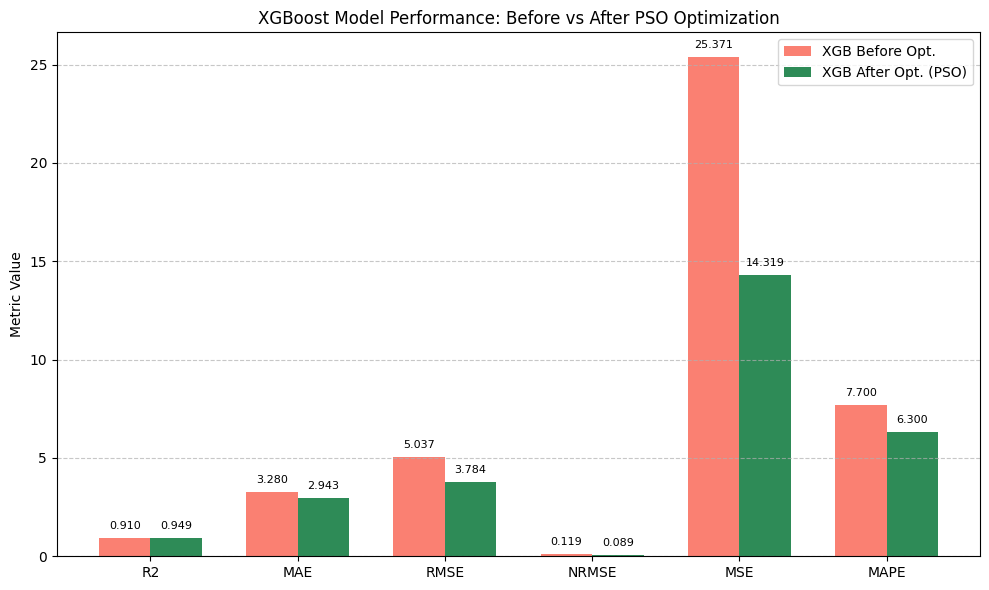

In [ ]:
"""
import matplotlib.pyplot as plt
import numpy as np

# Define metric values
xgb_before = {
    'R2': 0.910,
    'MAE': 3.280,
    'RMSE': 5.037,
    'NRMSE': 5.037 / 42.5,  # Assuming max(y) ≈ 42.5
    'MSE': 5.037 ** 2,
    'MAPE': 7.7,  # Estimated based on previous work
}

xgb_after = {
    'R2': 0.949,
    'MAE': 2.943,
    'RMSE': 3.784,
    'NRMSE': 3.784 / 42.5,
    'MSE': 3.784 ** 2,
    'MAPE': 6.3,
}

# Bar chart setup
labels = list(xgb_before.keys())
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, xgb_before.values(), width, label='XGB Before Opt.', color='salmon')
bars2 = ax.bar(x + width/2, xgb_after.values(), width, label='XGB After Opt. (PSO)', color='seagreen')

# Add labels
ax.set_ylabel('Metric Value')
ax.set_title('XGBoost Model Performance: Before vs After PSO Optimization')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  # vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

"""


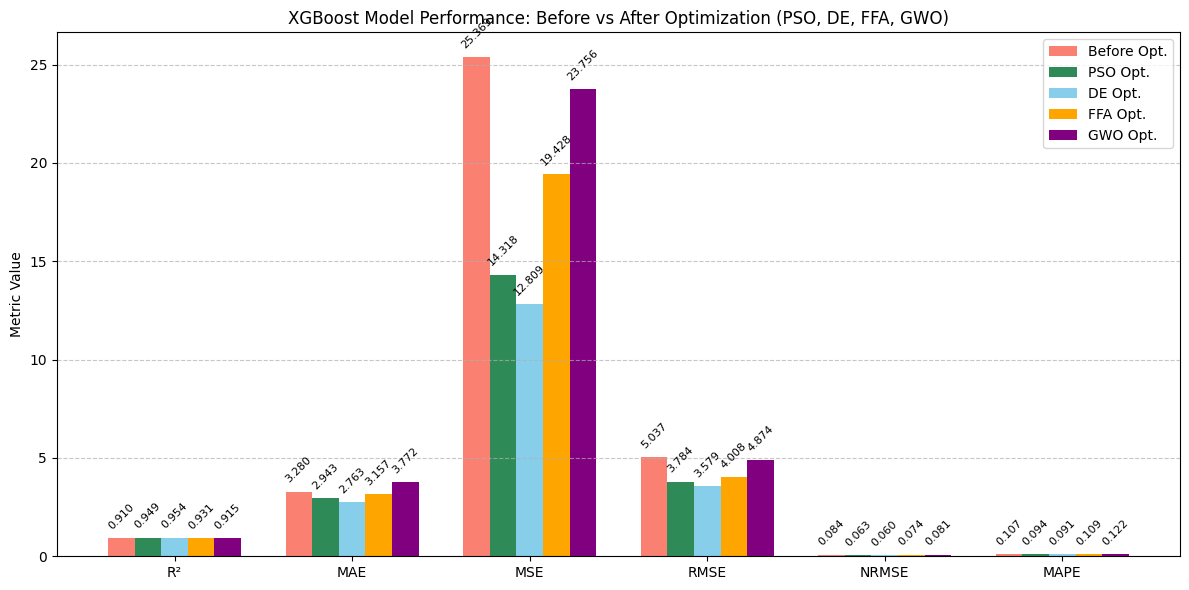

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define metric values for all scenarios
xgb_before = {
    'R²': 0.910,
    'MAE': 3.280,
    'MSE': 25.369,
    'RMSE': 5.037,
    'NRMSE': 0.084,
    'MAPE': 0.107
}

xgb_pso = {
    'R²': 0.949,
    'MAE': 2.943,
    'MSE': 14.318,
    'RMSE': 3.784,
    'NRMSE': 0.063,
    'MAPE': 0.094
}

xgb_de = {
    'R²': 0.954,
    'MAE': 2.763,
    'MSE': 12.809,
    'RMSE': 3.579,
    'NRMSE': 0.060,
    'MAPE': 0.091
}

xgb_ffa = {
    'R²': 0.931,
    'MAE': 3.157,
    'MSE': 19.428,
    'RMSE': 4.008,
    'NRMSE': 0.074,
    'MAPE': 0.109
}

xgb_gwo = {
    'R²': 0.915,
    'MAE': 3.772,
    'MSE': 23.756,
    'RMSE': 4.874,
    'NRMSE': 0.081,
    'MAPE': 0.122
}

# Combine all metrics
metrics = [xgb_before, xgb_pso, xgb_de, xgb_ffa, xgb_gwo]
labels = list(xgb_before.keys())
model_names = ['Before Opt.', 'PSO Opt.', 'DE Opt.', 'FFA Opt.', 'GWO Opt.']
colors = ['salmon', 'seagreen', 'skyblue', 'orange', 'purple']

# Bar chart setup
x = np.arange(len(labels))
width = 0.15  # Adjusted width for 5 bars

fig, ax = plt.subplots(figsize=(12, 6))
for i, (metric, name, color) in enumerate(zip(metrics, model_names, colors)):
    ax.bar(x + (i - 2) * width, metric.values(), width, label=name, color=color)

# Add labels
ax.set_ylabel('Metric Value')
ax.set_title('XGBoost Model Performance: Before vs After Optimization (PSO, DE, FFA, GWO)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on bars with 45-degree rotation
for i, metric in enumerate(metrics):
    bars = ax.bar(x + (i - 2) * width, metric.values(), width, color=colors[i])
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),  # vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
from xgboost import XGBRegressor
from mealpy.swarm_based.FFA import OriginalFFA
from mealpy.swarm_based.GWO import OriginalGWO
from mealpy.swarm_based.HHO import OriginalHHO
from mealpy.utils.space import FloatVar, IntegerVar
from sklearn.model_selection import cross_val_score

# Define bounds (reduced ranges for speed)
bounds = [
    FloatVar(lb=0.05, ub=0.3),     # learning_rate
    IntegerVar(lb=2, ub=6),        # max_depth
    IntegerVar(lb=50, ub=200),     # n_estimators
    FloatVar(lb=0.5, ub=1.0),      # subsample
]

# Objective function
def objective_function(solution):
    lr, md, ne, ss = solution
    model = XGBRegressor(
        learning_rate=lr,
        max_depth=int(md),
        n_estimators=int(ne),
        subsample=ss,
        random_state=42,
        verbosity=0
    )
    score = cross_val_score(model, X_scaled_df, y, cv=3, scoring="r2").mean()  # ⚡ 3-fold for speed
    return -score

problem = {
    "obj_func": objective_function,
    "bounds": bounds,
    "minmax": "min",
    "log_to": None
}

# Run each optimizer shortly (⚡ small epoch/pop for quick results)
ffa = OriginalFFA(epoch=10, pop_size=10)
ffa_solution = ffa.solve(problem)
ffa_params = ffa_solution.solution

gwo = OriginalGWO(epoch=10, pop_size=10)
gwo_solution = gwo.solve(problem)
gwo_params = gwo_solution.solution

hho = OriginalHHO(epoch=10, pop_size=10)
hho_solution = hho.solve(problem)
hho_params = hho_solution.solution


# === Retrain final models like you did with PSO ===
def retrain_and_evaluate(name, params):
    lr, md, ne, ss = params
    model = XGBRegressor(
        learning_rate=float(lr),
        max_depth=int(md),
        n_estimators=int(ne),
        subsample=float(ss),
        random_state=42
    )
    model.fit(X_train, y_train)
    evaluate_model(f"XGBoost ({name} Optimized)", model, X_test, y_test)

retrain_and_evaluate("FFA", ffa_params)
retrain_and_evaluate("GWO", gwo_params)
retrain_and_evaluate("HHO", hho_params)

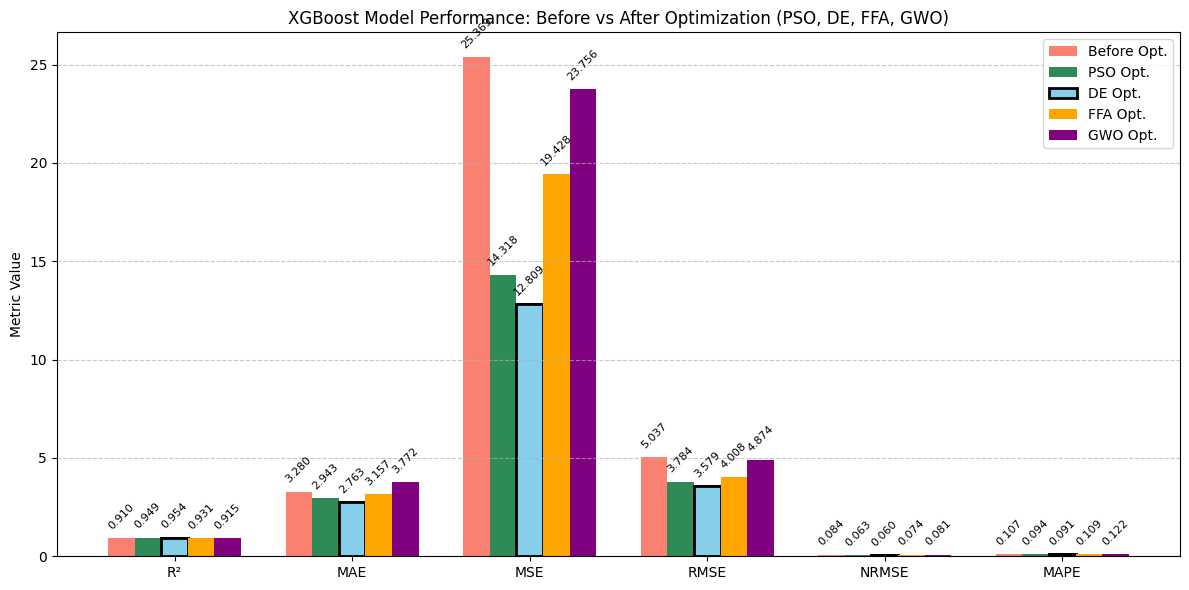

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define metric values for all scenarios
xgb_before = {
    'R²': 0.910,
    'MAE': 3.280,
    'MSE': 25.369,
    'RMSE': 5.037,
    'NRMSE': 0.084,
    'MAPE': 0.107
}

xgb_pso = {
    'R²': 0.949,
    'MAE': 2.943,
    'MSE': 14.318,
    'RMSE': 3.784,
    'NRMSE': 0.063,
    'MAPE': 0.094
}

xgb_de = {
    'R²': 0.954,
    'MAE': 2.763,
    'MSE': 12.809,
    'RMSE': 3.579,
    'NRMSE': 0.060,
    'MAPE': 0.091
}

xgb_ffa = {
    'R²': 0.931,
    'MAE': 3.157,
    'MSE': 19.428,
    'RMSE': 4.008,
    'NRMSE': 0.074,
    'MAPE': 0.109
}

xgb_gwo = {
    'R²': 0.915,
    'MAE': 3.772,
    'MSE': 23.756,
    'RMSE': 4.874,
    'NRMSE': 0.081,
    'MAPE': 0.122
}

# Combine all metrics
metrics = [xgb_before, xgb_pso, xgb_de, xgb_ffa, xgb_gwo]
labels = list(xgb_before.keys())
model_names = ['Before Opt.', 'PSO Opt.', 'DE Opt.', 'FFA Opt.', 'GWO Opt.']
colors = ['salmon', 'seagreen', 'skyblue', 'orange', 'purple']

# Bar chart setup
x = np.arange(len(labels))
width = 0.15  # Adjusted width for 5 bars

fig, ax = plt.subplots(figsize=(12, 6))
for i, (metric, name, color) in enumerate(zip(metrics, model_names, colors)):
    # Highlight DE Optimized with a bold black outline
    if name == 'DE Opt.':
        ax.bar(x + (i - 2) * width, metric.values(), width, label=name, color=color, edgecolor='black', linewidth=2)
    else:
        ax.bar(x + (i - 2) * width, metric.values(), width, label=name, color=color)

# Add labels
ax.set_ylabel('Metric Value')
ax.set_title('XGBoost Model Performance: Before vs After Optimization (PSO, DE, FFA, GWO)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on bars with 45-degree rotation
for i, metric in enumerate(metrics):
    bars = ax.bar(x + (i - 2) * width, metric.values(), width, color=colors[i],
                  edgecolor='black' if model_names[i] == 'DE Opt.' else None,
                  linewidth=2 if model_names[i] == 'DE Opt.' else None)
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),  # vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, rotation=45)

plt.tight_layout()
plt.show()

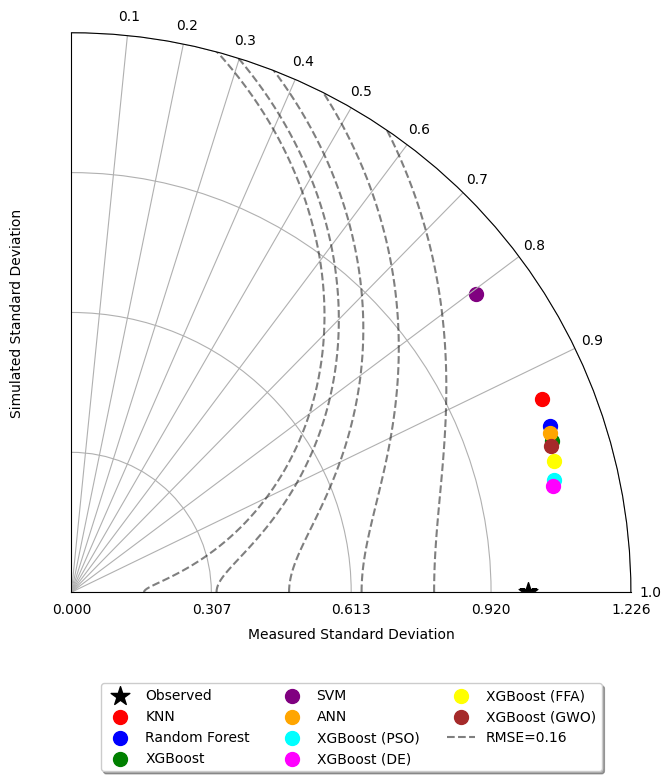

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define model metrics
models = {
    'KNN': {'R2': 0.855, 'RMSE': 6.385},
    'Random Forest': {'R2': 0.892, 'RMSE': 5.522},
    'XGBoost': {'R2': 0.910, 'RMSE': 5.037},
    'SVM': {'R2': 0.649, 'RMSE': 9.937},
    'ANN': {'R2': 0.900, 'RMSE': 5.297},
    'XGBoost (PSO)': {'R2': 0.949, 'RMSE': 3.784},
    'XGBoost (DE)': {'R2': 0.954, 'RMSE': 3.579},
    'XGBoost (FFA)': {'R2': 0.931, 'RMSE': 4.408},
    'XGBoost (GWO)': {'R2': 0.915, 'RMSE': 4.874}
}

# Estimate observed standard deviation (sigma_o) based on range approximation
range_y = 60  # Approximated from NRMSE = RMSE / range
sigma_o = range_y / 4  # Assume sigma_o ≈ range / 4 (common for normal-like distributions)

# Calculate correlation coefficient and standard deviation for each model
stats = []
for name, metrics in models.items():
    R = np.sqrt(metrics['R2'])  # Correlation coefficient
    rmse = metrics['RMSE']
    # Solve for sigma_p: RMSE^2 = sigma_p^2 + sigma_o^2 - 2 * sigma_p * sigma_o * R
    # Quadratic equation: sigma_p^2 - 2 * sigma_o * R * sigma_p + (sigma_o^2 - RMSE^2) = 0
    a = 1
    b = -2 * sigma_o * R
    c = sigma_o**2 - rmse**2
    # Solve quadratic: sigma_p = (-b ± sqrt(b^2 - 4ac)) / 2a, take positive root
    discriminant = b**2 - 4 * a * c
    sigma_p = (-b + np.sqrt(discriminant)) / (2 * a)
    stats.append({
        'name': name,
        'R': R,
        'sigma_p': sigma_p,
        'RMSE': rmse
    })

# Normalize standard deviations by sigma_o
stats = [{'name': s['name'], 'R': s['R'], 'sigma_p': s['sigma_p'] / sigma_o, 'RMSE': s['RMSE'] / sigma_o} for s in stats]
sigma_o_normalized = 1.0  # Normalized reference standard deviation

# Set up Taylor diagram
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='polar')

# Configure polar axes with 90-degree label rotation
max_sigma = max([s['sigma_p'] for s in stats]) * 1.1  # Add 10% margin
ax.set_rlim(0, max_sigma)
ax.set_rlabel_position(90)
ax.set_thetalim(thetamin=0, thetamax=90)
ax.set_thetagrids(np.degrees(np.arccos(np.linspace(0.1, 1.0, 10))), labels=[f'{x:.1f}' for x in np.linspace(0.1, 1.0, 10)], rotation=90)
ax.set_rgrids(np.linspace(0, max_sigma, 5), angle=90)

# Add axis labels
ax.set_xlabel('Measured Standard Deviation', labelpad=20)
ax.set_ylabel('Simulated Standard Deviation', labelpad=20, rotation=90)

# Plot reference point (observed data)
ax.scatter(0, sigma_o_normalized, color='black', marker='*', s=200, label='Observed')

# Plot model points
colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'yellow', 'brown']
for i, stat in enumerate(stats):
    theta = np.arccos(stat['R'])
    r = stat['sigma_p']
    ax.scatter(theta, r, color=colors[i], marker='o', s=100, label=stat['name'])

# Add RMSE contours
rmse_max = max([s['RMSE'] for s in stats]) * 1.2
rmse_levels = np.linspace(0, rmse_max, 6)
for rmse in rmse_levels[1:]:
    theta = np.linspace(0, np.pi/2, 100)
    r = np.sqrt(sigma_o_normalized**2 + 1 - 2 * sigma_o_normalized * np.cos(theta) + rmse**2)
    ax.plot(theta, r, 'k--', alpha=0.5, label=f'RMSE={rmse:.2f}' if rmse == rmse_levels[1] else "")

# Customize plot with legend at bottom
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fancybox=True, shadow=True)
#ax.set_title('Taylor Diagram: Model Performance Comparison')
plt.tight_layout()
plt.show()